# 4 — Programowanie dynamiczne (DP): Gridworld + FrozenLake (wersja studencka — projekt)

Lektura: Sutton & Barto, rozdz. 4.

**Cel laboratorium (ok. 4h pracy własnej):** zaimplementować i przetestować podstawowe algorytmy DP dla MDP
przy założeniu **znanego modelu** (format `P[s][a]`).

W tym notebooku zrobisz 4 kroki:
- **policy evaluation** (obliczanie $v_\pi$),
- **policy improvement** (zachłanna poprawa),
- **policy iteration** (pętla evaluation→improvement),
- **value iteration** (bezpośrednio $v_*$).

**Jak pracować:** w komórkach oznaczonych `TODO` wpisz własną implementację.
Nie ma jednej „jedynej” poprawnej wersji,
ale wyniki powinny być spójne.

> Wskazówka organizacyjna: najpierw zaimplementuj funkcje z sekcji 1–4, dopiero potem uruchamiaj komórki z eksperymentami.


## DP używa pełnych backupów

Programowanie dynamiczne zakłada, że znamy model środowiska i możemy sumować po wszystkich możliwych kolejnych (...):
$$
\sum_{s',r} p(s',r\mid s,a)[\cdot]
$$

W praktyce: mamy dostęp do struktury `P[s][a]`, czyli listy wyników `(prob, s2, r, terminated)`.


## Setup

Ten notebook nie wymaga Gym/Gymnasium do części z Gridworld.

Dla FrozenLake:
- Jeśli masz `gymnasium`, możesz używać `env.unwrapped.P`.
- Żeby notebook był samowystarczalny, poniżej budujemy także model FrozenLake w czystym Pythonie.

> **Colab (opcjonalnie):** jeśli potrzebujesz, zainstaluj:
> ```
> !pip -q install "gymnasium[toy-text]"
> ```


In [2]:
import numpy as np


In [3]:
def pretty_matrix_as_grid(v: np.ndarray, nrow: int, ncol: int, decimals: int = 1):
    """Wyświetla wektor wartości jako siatkę nrow x ncol."""
    grid = np.asarray(v, dtype=float).reshape(nrow, ncol)
    with np.printoptions(precision=decimals, suppress=True):
        print(grid)

def action_arrows(pi_det: np.ndarray, nrow: int, ncol: int, arrows):
    """Wyświetla deterministyczną politykę jako strzałki w siatce."""
    out = []
    for r in range(nrow):
        row = []
        for c in range(ncol):
            s = r * ncol + c
            a = int(pi_det[s])
            row.append(arrows.get(a, '?'))
        out.append(' '.join(row))
    print('\n'.join(out))


def build_P_r_for_policy(P, pi: np.ndarray):
    """Buduje (P_pi, r_pi) dla danej polityki pi na podstawie modelu P[s][a].

    Zwraca:
    - P_pi: macierz przejść (nS x nS)
    - r_pi: wektor nagród oczekiwanych (nS,)

    Uwaga: dla zadań epizodycznych (FrozenLake) działa poprawnie, o ile stany terminalne są absorbujące
    z nagrodą 0 (tak jest w standardowym FrozenLake).
    """
    nS, nA = pi.shape
    P_pi = np.zeros((nS, nS), dtype=float)
    r_pi = np.zeros(nS, dtype=float)

    for s in range(nS):
        for a in range(nA):
            w = float(pi[s, a])
            if w == 0.0:
                continue
            for (p, s2, r, terminated) in P[s][a]:
                P_pi[s, int(s2)] += w * float(p)
                r_pi[s] += w * float(p) * float(r)
    return P_pi, r_pi


def evaluate_policy_linear_system(P_pi: np.ndarray, r_pi: np.ndarray, gamma: float) -> np.ndarray:
    """Dokładna ewaluacja polityki przez układ liniowy: (I - gamma P_pi) v = r_pi."""
    nS = P_pi.shape[0]
    I = np.eye(nS)
    return np.linalg.solve(I - gamma * P_pi, r_pi)


In [4]:
def build_gridworld_AB_P():
    """Gridworld 5x5 z A/B teleportami (jak w rozdz. 3).

    Akcje (dla Gridworld): 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT.
    Przejścia są deterministyczne: P[s][a] ma jeden wpis z p=1.0.

    Zwraca: P, nS, nA, nrow, ncol
    """
    nrow, ncol = 5, 5
    nS, nA = nrow * ncol, 4
    P = {s: {a: [] for a in range(nA)} for s in range(nS)}

    # Specjalne pozycje A/B
    A = (0, 1); Aprime = (4, 1); reward_A = 10.0
    B = (0, 3); Bprime = (2, 3); reward_B = 5.0

    def s2pos(s):
        return (s // ncol, s % ncol)

    def pos2s(r, c):
        return r * ncol + c

    moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}

    for s in range(nS):
        r, c = s2pos(s)

        # teleporty mają priorytet
        if (r, c) == A:
            s2 = pos2s(*Aprime)
            for a in range(nA):
                P[s][a] = [(1.0, s2, reward_A, False)]
            continue
        if (r, c) == B:
            s2 = pos2s(*Bprime)
            for a in range(nA):
                P[s][a] = [(1.0, s2, reward_B, False)]
            continue

        # standardowe ruchy + kara za wyjście poza planszę
        for a in range(nA):
            dr, dc = moves[a]
            r2, c2 = r + dr, c + dc
            if (r2 < 0) or (r2 >= nrow) or (c2 < 0) or (c2 >= ncol):
                s2 = s
                reward = -1.0
            else:
                s2 = pos2s(r2, c2)
                reward = 0.0
            P[s][a] = [(1.0, s2, reward, False)]

    return P, nS, nA, nrow, ncol


In [5]:
def build_frozenlake_P(desc, is_slippery: bool = False):
    """
    Buduje model FrozenLake w formacie P[s][a] bez użycia Gym.

    desc: lista stringów opisujących mapę, np.
          ["SFFF",
           "FHFH",
           "FFFH",
           "HFFG"]

    Konwencja akcji (jak w Gym):
      0 = LEFT, 1 = DOWN, 2 = RIGHT, 3 = UP

    Nagroda:
      +1 za wejście na G, w pozostałych przypadkach 0.

    Stany terminalne:
      H (hole) i G (goal).
    """

    # Zamieniamy opis mapy na tablicę znaków
    desc = np.asarray([list(row) for row in desc], dtype='<U1')
    nrow, ncol = desc.shape
    nS, nA = nrow * ncol, 4   # liczba stanów i akcji

    # Indeksy akcji (zgodne z Gym)
    LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3

    # Wektory ruchu dla każdej akcji
    moves = {
        LEFT:  (0, -1),
        DOWN:  (1,  0),
        RIGHT: (0,  1),
        UP:    (-1, 0),
    }

    # Zamiana (r, c) -> indeks stanu
    def to_s(r, c):
        return r * ncol + c

    # Jeden krok z pozycji (r, c) dla akcji a
    def step_from(r, c, a):
        dr, dc = moves[a]
        r2, c2 = r + dr, c + dc

        # FrozenLake: wyjście poza planszę = zostajemy w miejscu
        if (r2 < 0) or (r2 >= nrow) or (c2 < 0) or (c2 >= ncol):
            r2, c2 = r, c

        return r2, c2

    # Inicjalizacja struktury P[s][a]
    P = {s: {a: [] for a in range(nA)} for s in range(nS)}

    # Iterujemy po wszystkich polach planszy
    for r in range(nrow):
        for c in range(ncol):
            s = to_s(r, c)
            tile = desc[r, c]

            # Stany terminalne (H i G):
            # są absorbujące — niezależnie od akcji zostajemy w tym samym stanie
            if tile in ('H', 'G'):
                for a in range(nA):
                    P[s][a] = [(1.0, s, 0.0, True)]
                continue

            # Stany nieterminalne
            for a in range(nA):
                outcomes = []

                # Wersja śliska: akcja nie realizuje się dokładnie
                if is_slippery:
                    # Faktyczna akcja to a-1, a, a+1 z prawd. 1/3
                    candidates = [(a - 1) % 4, a, (a + 1) % 4]
                    probs = [1/3, 1/3, 1/3]
                else:
                    # Wersja deterministyczna
                    candidates = [a]
                    probs = [1.0]

                # Dla każdej możliwej „rzeczywistej” akcji
                for a_real, p in zip(candidates, probs):
                    r2, c2 = step_from(r, c, a_real)
                    s2 = to_s(r2, c2)
                    tile2 = desc[r2, c2]

                    # Sprawdzamy, czy trafiliśmy w stan terminalny
                    terminated = tile2 in ('H', 'G')

                    # Nagroda tylko za wejście na G
                    reward = 1.0 if tile2 == 'G' else 0.0

                    outcomes.append((float(p), int(s2), float(reward), bool(terminated)))

                # Scalanie identycznych następstw
                # (różne a_real mogą prowadzić do tego samego s2)
                merged = {}
                for p, s2, rwd, term in outcomes:
                    key = (s2, rwd, term)
                    merged[key] = merged.get(key, 0.0) + p

                # Finalna lista wyników dla (s, a)
                P[s][a] = [
                    (p, s2, rwd, term)
                    for (s2, rwd, term), p in merged.items()
                ]

    return P, nS, nA, nrow, ncol, desc


In [20]:
# Środowisko 1: Gridworld z A/B (continuing)
P_gw, nS_gw, nA_gw, nrow_gw, ncol_gw = build_gridworld_AB_P()

# Środowisko 2: FrozenLake 4x4 (episodic)
desc4 = [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG",
]
P_fl_det, nS_fl, nA_fl, nrow_fl, ncol_fl, desc_fl = build_frozenlake_P(desc4, is_slippery=False)
P_fl_slip, _, _, _, _, _ = build_frozenlake_P(desc4, is_slippery=True)

print('Gridworld: nS=', nS_gw, ' nA=', nA_gw, ' shape=', (nrow_gw, ncol_gw))
print('FrozenLake: nS=', nS_fl, ' nA=', nA_fl, ' shape=', (nrow_fl, ncol_fl))
print('FrozenLake map:')
print('\n'.join(''.join(row) for row in desc_fl))
print('FrozenLake (slippery): nS=', nS_fl, ' nA=', nA_fl, ' shape=', (nrow_fl, ncol_fl))
print('FrozenLake map:')
print('\n'.join(''.join(row) for row in desc_fl))

# Mapy akcji -> strzałki (do wizualizacji polityk)
arrows_gw = {0:'↑', 1:'→', 2:'↓', 3:'←'}  # Gridworld: UP, RIGHT, DOWN, LEFT
arrows_fl = {0:'←', 1:'↓', 2:'→', 3:'↑'}  # FrozenLake: LEFT, DOWN, RIGHT, UP


Gridworld: nS= 25  nA= 4  shape= (5, 5)
FrozenLake: nS= 16  nA= 4  shape= (4, 4)
FrozenLake map:
SFFF
FHFH
FFFH
HFFG
FrozenLake (slippery): nS= 16  nA= 4  shape= (4, 4)
FrozenLake map:
SFFF
FHFH
FFFH
HFFG


### Co pokazuje ten fragment?

Ten kod **porównuje dwa różne środowiska MDP**, które będziemy dalej wykorzystywać w kursie:

- **Gridworld z A/B teleportami** — zadanie ciągłe (continuing),
- **FrozenLake 4×4** — zadanie epizodyczne (episodic).

---

### Najważniejsze obserwacje

- Oba środowiska są opisane **tym samym modelem MDP**:
  - mają `P[s][a]`,
  - mają `nS` (liczbę stanów),
  - mają `nA` (liczbę akcji).
  Dzięki temu **te same algorytmy DP/RL działają bez zmian**.

- **Gridworld**:
  - nie ma stanów terminalnych,
  - agent działa bez końca,
  - wartości stabilizuje dyskontowanie (`gamma < 1`).

- **FrozenLake**:
  - ma stany terminalne (`H`, `G`),
  - epizod się kończy po wejściu w dziurę lub do celu,
  - to klasyczny przykład zadania epizodycznego.

- Dla FrozenLake pokazujemy też dwie wersje:
  - deterministyczną (`is_slippery=False`),
  - losową (`is_slippery=True`),
  co później pozwala zobaczyć wpływ losowości na wartości i polityki.

---

### Podsumowanie

> Ten fragment pokazuje, że różne środowiska mogą mieć bardzo inną dynamikę, ale jeśli są MDP, możemy je analizować tym samym aparatem matematycznym.


### Uwaga: dlaczego nie analizujemy wersji `slippery`?

W tym rozdziale **budujemy** zarówno deterministyczną, jak i losową (`slippery`) wersję FrozenLake,
ale **wyniki prezentujemy tylko dla wersji deterministycznej**.

Powód jest dydaktyczny:
- celem rozdziału 4 jest zrozumienie **mechaniki Dynamic Programming**,
- losowość środowiska nie wnosi tu nowej idei, a tylko utrudnia interpretację wyników.

Wersja `slippery` wróci później:
- gdy będziemy porównywać DP z RL,
- oraz gdy losowość stanie się kluczowym elementem problemu.




### Ramka: deterministyczne vs `slippery` w równaniach Bellmana

Wszystkie wzory z zajęć **pozostają bez zmian** niezależnie od tego,
czy środowisko jest deterministyczne, czy losowe (`slippery`).

#### Bez `slippery` (deterministycznie)
- Każda akcja ma **jeden skutek**.
- W `P[s][a]` jest pojedynczy wpis z prawdopodobieństwem 1.
- Równanie Bellmana redukuje się do:
  $$
  V(s) = r + \gamma V(s').
  $$

#### Z `slippery` (losowo)
- Ta sama akcja ma **kilka możliwych skutków**.
- W `P[s][a]` jest kilka wpisów z różnymi prawdopodobieństwami.
- Równanie Bellmana liczy **wartość oczekiwaną**:
  $$
  V(s) = \sum_i p_i \big(r_i + \gamma V(s'_i)\big).
  $$

#### Co to zmienia w praktyce?
- **Nie zmienia teorii ani algorytmów** (policy evaluation, value iteration).
- Zmienia **liczby** w obliczeniach i **intuicję decyzji**:
  - polityka optymalna zaczyna unikać ryzykownych ruchów,
  - „bezpieczne” ścieżki stają się bardziej atrakcyjne.

---

**Podsumowanie:**  
`slippery` nie zmienia równań Bellmana — sprawia tylko, że każda akcja jest oceniana przez wartość oczekiwaną zamiast przez jeden deterministyczny skutek.


## 1. Iteracyjna ewaluacja polityki (policy evaluation)

Chcemy policzyć wartość $v_\pi$ dla ustalonej polityki $\pi$.

Backup Bellmana (expectation):
$$
v_{k+1}(s) \leftarrow \sum_a \pi(a\mid s) \sum_{s',r} p(s',r\mid s,a)\,[r + \gamma v_k(s')].
$$

W DP robimy to iteracyjnie (kolejne przybliżenia), zamiast od razu rozwiązywać układ liniowy.


### Ćwiczenie 1 — Iteracyjna ewaluacja polityki

**Cel:** policzyć funkcję wartości `v_π` dla *zadanej* polityki `π`, używając
iteracyjnego backupu Bellmana (Dynamic Programming), zamiast rozwiązywania układu równań.

**Co robimy:**
- polityka `π` jest ustalona (brak `max`),
- wielokrotnie aktualizujemy wartości stanów zgodnie z definicją Bellmana,
- przerywamy, gdy zmiany są bardzo małe (`theta`).

**Dlaczego to ważne:**
- to dokładnie ten sam obiekt `v_π`, co w rozdz. 3,
- metoda iteracyjna skaluje się lepiej i jest fundamentem DP,
- przygotowuje grunt pod *policy improvement* i *policy iteration*.

**Sanity check:** porównujemy wynik iteracyjny z rozwiązaniem macierzowym — powinny się zgadzać.



![Policy evaluation – schemat](figures/policy_evaluation_pseudocode.png)

Uwaga: w implementacji równania Bellmana występują dwie zagnieżdżone sumy:
najpierw po akcjach (ważone przez π), a następnie po możliwych wynikach środowiska (ważone przez p).

In [7]:
import numpy as np


def iterative_policy_evaluation(P, pi: np.ndarray,
                                gamma: float = 0.9,
                                theta: float = 1e-10,
                                max_iters: int = 100_000):
    """Iteracyjna ewaluacja polityki (policy evaluation) dla modelu `P[s][a]`.

    TODO (Ćwiczenie 1)
    Napisz funkcję, która liczy przybliżenie wartości stanów `v_pi` dla *ustalonej* polityki `pi`.

    Definicja (backup Bellmana — expectation):
        v(s) <- sum_a pi(a|s) * sum_{s',r} p(s',r|s,a) * [ r + gamma * v(s') ]
    Parametry:
    - P: model środowiska w postaci P[s][a] = [(p, s2, r, terminated), ...]
    - pi: polityka w postaci macierzy (nS x nA), gdzie pi[s,a] = π(a|s)
    - gamma: współczynnik dyskontowania
    - theta: próg zbieżności (maks. zmiana wartości w iteracji)
    - max_iters: maksymalna liczba iteracji (zabezpieczenie)

    Zwraca:
    - v: wektor wartości stanów v_pi (shape: nS)
    Wejście:
    - P: model w formacie słownika: P[s][a] = lista krotek (prob, s2, r, terminated)
    - pi: macierz (nS, nA) z rozkładami pi(a|s)

    Wymagania:
    - zatrzymanie po zbieżności: max zmiana w iteracji < theta (zmienna `delta`)
    - obsłuż stany terminalne:
        jeśli `terminated=True`, to NIE bootstrappuj z v[s2] (zamiast tego użyj 0)
    - zwróć wektor v (shape: (nS,))
    - Stany terminalne: jeśli przejście kończy epizod, to nie dodajemy składnika γ·v(s').
        Wartość po terminalu jest z definicji równa 0.
    Wskazówki (bez narzucania implementacji):
    - Zacznij od `v = zeros(nS)`.
    - W każdej iteracji wykonaj "sweep" po wszystkich stanach.
    - Możesz aktualizować `v[s]` in-place (często szybciej), albo 
    synchronicznie (przez kopię).
    Zmienna delta mierzy, jak bardzo naruszone jest równanie 
    Bellmana — gdy delta → 0, wartości są bliskie rozwiązania dokładnego.
    Po zaimplementowaniu usuń `raise NotImplementedError`.
    """

    # TODO: pobierz nS, nA z `pi.shape`
    # TODO: zainicjalizuj `v`
    # TODO: pętla po iteracjach, aktualizacja delta, warunek stopu

    # TODO 1: zainicjalizuj wektor wartości v(s), np. zerami

    # TODO 2: wykonuj kolejne iteracje (sweepy po stanach)
    #         - w każdej iteracji oblicz nowe wartości stanów
    #         - śledź maksymalną zmianę delta

    # TODO 3: dla danego stanu s:
    #         - policz sumę po akcjach a zgodnie z pi[s,a]
    #         - dla każdej akcji zsumuj wkłady z P[s][a]
    #         - pamiętaj o obsłudze terminated (brak bootstrapu)

    # TODO 4: jeśli delta < theta, przerwij iteracje

    # TODO 5: zwróć wektor v
    nS,nA = pi.shape
    v= np.zeros(nS)
    for it in range(max_iters):
        delta = 0
        for s in range(nS):
            v_old = v[s]
            v_new = 0
            for a in range(nA):
                w = pi[s,a]
                if w==0: continue
                q=0
                for (p,s2,r,terminated) in P[s][a]:
                    if terminated:
                        q+=p*r
                    else:
                        q+=p*(r+gamma *v[s2])
                v_new+=w*q
            v[s]=v_new
            delta = max(delta,abs(v_old-v_new))
        if delta < theta:
            break
    return v
    #raise NotImplementedError('TODO: zaimplementuj iterative_policy_evaluation')


### Policy evaluation jako problem algebry liniowej (referencyjnie) - wprowadzone na poprzedniej lekcji.

Dla ustalonej polityki π równanie Bellmana można zapisać w postaci macierzowej:

v = r_π + γ P_π v

gdzie:
- v ∈ R^{nS} — wektor wartości stanów,
- r_π — wektor oczekiwanych nagród,
- P_π — macierz przejść pod polityką π.

Po przekształceniu:

(I − γ P_π) v = r_π

Jest to zwykły układ równań liniowych, który można rozwiązać
za pomocą metod algebry liniowej (np. eliminacji Gaussa).

To rozwiązanie jest:
- **dokładne** (w granicach numeryki),
- ale wymaga przechowywania macierzy nS × nS
  i ma koszt obliczeniowy rzędu O(nS³).

Dlatego w praktyce RL stosujemy **metody iteracyjne**,
które są znacznie tańsze pamięciowo i skalują się lepiej.


### Mini-przykład (2 stany)

Załóżmy:
- dwa stany: s₀, s₁,
- jedna akcja (polityka trywialna),
- przejścia:
  - s₀ → s₁ z nagrodą 1,
  - s₁ → s₁ z nagrodą 0,
- γ = 0.9.

Równania Bellmana:

v(s₀) = 1 + 0.9 v(s₁)
v(s₁) = 0 + 0.9 v(s₁)

Z drugiego równania:
0.1 v(s₁) = 0 ⇒ v(s₁) = 0

Podstawiając:
v(s₀) = 1

To dokładnie ten sam wynik, do którego dochodzi
iteracyjna policy evaluation — tylko „na raty”.


### Od równania Bellmana do układu równań liniowych

Dla ustalonej polityki π równanie Bellmana ma postać:

v_π = r_π + γ P_π v_π

Jest to równanie, w którym niewiadomą jest cały wektor v_π.
Przenosząc wyrazy na jedną stronę, otrzymujemy:

(I − γ P_π) v_π = r_π

To jest zwykły układ równań liniowych, znany z algebry liniowej.

- macierz (I − γ P_π) ma rozmiar nS × nS,
- wektor r_π ma rozmiar nS,
- rozwiązaniem jest wektor wartości stanów v_π.

Metoda iteracyjna policy evaluation rozwiązuje dokładnie to samo równanie,
ale metodą kolejnych przybliżeń, bez jawnego budowania macierzy.


In [8]:
def evaluate_policy_linear_system_from_model(P, pi, gamma):
    """
    Dokładna ewaluacja polityki przez rozwiązanie układu równań liniowych.

    TODO (opcjonalne):
    - zbuduj macierz P_pi i wektor r_pi dla danej polityki
    - rozwiąż układ (I - gamma * P_pi) v = r_pi

    Uwaga:
    - metoda referencyjna (sanity-check),
    - kosztowna pamięciowo i obliczeniowo,
    - sensowna tylko dla małych środowisk.
    """
    P_pi, r_pi = build_P_r_for_policy(P, pi)
    I = np.eye(P_pi.shape[0])
    v = np.linalg.solve(I - gamma * P_pi, r_pi)
    return v

In [39]:
import time
import sys

def benchmark_policy_evaluation(P, pi, gamma):
    # Iteracyjna
    t0 = time.time()
    v_iter = iterative_policy_evaluation(P, pi, gamma)
    t_iter = time.time() - t0

    # Liniowa
    t0 = time.time()
    v_lin = evaluate_policy_linear_system_from_model(P, pi, gamma)
    t_lin = time.time() - t0

    # Różnica
    err = np.max(np.abs(v_iter - v_lin))

    print("Iterative PE:")
    print(f"  time = {t_iter:.4f} s")
    print(f"  memory ~ O(nS)")

    print("Linear system PE:")
    print(f"  time = {t_lin:.4f} s")
    print(f"  memory ~ O(nS^2)")

    print(f"Max |v_iter - v_linear| = {err:.2e}")


Max |v_iter - v_linear| = 4.4990855485593784e-10


### Dlaczego w RL używamy metod iteracyjnych?

Rozwiązanie układu liniowego jest eleganckie i dokładne,
ale jego koszt rośnie bardzo szybko wraz z liczbą stanów.

Metody iteracyjne:
- nie wymagają budowy pełnej macierzy P_π,
- używają tylko lokalnych informacji o przejściach,
- są naturalnym punktem wyjścia do metod bezmodelowych (TD, Q-learning).

Dlatego policy evaluation w RL
traktujemy jako **problem stałego punktu**, a nie jako klasyczne
zadanie z algebry liniowej.


In [43]:
# Przykład: Gridworld 5x5
P, nS, nA, nrow, ncol = build_gridworld_AB_P()

# Polityka losowa (jednolita)
pi = np.ones((nS, nA)) / nA

gamma = 0.9

In [45]:
v_iter = iterative_policy_evaluation(P, pi, gamma=gamma)
v_lin = evaluate_policy_linear_system_from_model(P, pi, gamma=gamma)
max_diff = np.max(np.abs(v_iter - v_lin))
print("Max |v_iter - v_linear| =", max_diff)


Max |v_iter - v_linear| = 4.4990855485593784e-10


### Sanity check (zalecane)

Dla małych środowisk porównaj wynik iteracyjny z rozwiązaniem
układu równań liniowych `(I − γP_π)v = r_π`.
Obie metody powinny dać bardzo zbliżone wyniki (różnice rzędu `1e−6`).
To porównanie pokazuje, że metoda iteracyjna faktycznie rozwiązuje to samo równanie co metoda liniowa — tylko innym (tańszym) sposobem.


### Ćwiczenie: Policy evaluation w FrozenLake (zadanie epizodyczne)

W tym ćwiczeniu stosujemy iteracyjną ewaluację polityki
do środowiska **FrozenLake**, które jest zadaniem *epizodycznym*.

- epizod kończy się, gdy agent wpadnie do dziury (`H`) lub dotrze do celu (`G`),
- jedyna dodatnia nagroda (+1) jest przyznawana za wejście na pole `G`,
- pozostałe przejścia mają nagrodę 0.

Analizujemy **politykę losową**:
agent w każdym stanie wybiera jedną z 4 akcji z jednakowym prawdopodobieństwem.

Wartość stanu `v_π(s)` można interpretować jako:
> *oczekiwaną (zdyskontowaną) nagrodę,
> czyli w przybliżeniu szansę dotarcia do celu,
> jeśli startujemy w stanie `s` i poruszamy się losowo.*

**Czego się spodziewać:**
- stany bliżej celu powinny mieć większe wartości,
- stany prowadzące do dziur – mniejsze,
- wartości w FrozenLake są zwykle znacznie mniejsze niż w Gridworld,
  ponieważ nagroda pojawia się tylko na końcu epizodu.


In [46]:
# --- Gridworld: ewaluacja polityki równoprawdopodobnej (jak w książce) ---

gamma_gw = 0.9
# Współczynnik dyskontowania; Gridworld jest zadaniem ciągłym

# Polityka równoprawdopodobna:
# w każdym stanie każda z 4 akcji ma prawdopodobieństwo 1/4
pi_gw_rand = np.ones((nS_gw, nA_gw), dtype=float) / nA_gw

# Iteracyjnie liczymy v_pi dla tej polityki (policy evaluation)
v_gw = iterative_policy_evaluation(P_gw, pi_gw_rand, gamma=gamma_gw)

print('Gridworld: v_pi (polityka równoprawdopodobna), tabela 5x5:')
# Wyświetlamy wartości stanów w formie siatki (jak w książce)
pretty_matrix_as_grid(v_gw, nrow_gw, ncol_gw, decimals=1)


# --- (opcjonalnie) sanity check: porównanie z rozwiązaniem macierzowym ---

# Budujemy macierze P_pi i r_pi dla tej samej polityki
P_pi, r_pi = build_P_r_for_policy(P_gw, pi_gw_rand)

# Liczymy v_pi dokładnie, rozwiązując układ równań Bellmana
v_gw_lin = evaluate_policy_linear_system(P_pi, r_pi, gamma_gw)

# Sprawdzamy, że metoda iteracyjna i macierzowa dają ten sam wynik
print('\nMax |v_iter - v_lin| =',
      float(np.max(np.abs(v_gw - v_gw_lin))))


Gridworld: v_pi (polityka równoprawdopodobna), tabela 5x5:
[[ 3.3  8.8  4.4  5.3  1.5]
 [ 1.5  3.   2.3  1.9  0.5]
 [ 0.1  0.7  0.7  0.4 -0.4]
 [-1.  -0.4 -0.4 -0.6 -1.2]
 [-1.9 -1.3 -1.2 -1.4 -2. ]]

Max |v_iter - v_lin| = 4.4990855485593784e-10


## Środowisko FrozenLake (model P[s][a])

W dalszej części notebooka korzystamy z modelu środowiska FrozenLake,
zbudowanego wcześniej za pomocą funkcji `build_frozenlake_P`.

- `P_fl_det` — wersja deterministyczna (bez poślizgu),
- `P_fl_slip` — wersja śliska (akcje są losowo zaburzane),
- `desc_fl` — mapa planszy (S, F, H, G).

Przypomnienie mapy:


In [47]:
# --- FrozenLake (deterministyczne): ewaluacja polityki losowej ---

gamma_fl = 0.99
# FrozenLake jest zadaniem epizodycznym,
# dlatego często przyjmuje się gamma bliskie 1

# Polityka losowa:
# w każdym stanie losujemy jedną z 4 akcji z jednakowym prawdopodobieństwem
pi_fl_rand = np.ones((nS_fl, nA_fl), dtype=float) / nA_fl

# Iteracyjnie liczymy v_pi dla tej polityki w FrozenLake
v_fl = iterative_policy_evaluation(P_fl_det, pi_fl_rand, gamma=gamma_fl)

print('FrozenLake (deterministyczne): v_pi (polityka losowa), tabela 4x4:')
# Wyświetlamy wartości stanów jako siatkę 4x4
pretty_matrix_as_grid(v_fl, nrow_fl, ncol_fl, decimals=2)

FrozenLake (deterministyczne): v_pi (polityka losowa), tabela 4x4:
[[0.01 0.01 0.02 0.01]
 [0.01 0.   0.04 0.  ]
 [0.03 0.08 0.14 0.  ]
 [0.   0.17 0.43 0.  ]]


### Dlaczego wartości `v_π` są tu małe?

- Oceniamy **politykę losową**, która rzadko prowadzi do celu.
- FrozenLake jest **zadaniem epizodycznym**:
  - jedyna dodatnia nagroda to `+1` za wejście na `G`,
  - wiele epizodów kończy się bez żadnej nagrody.
- Wartość `v_π(s)` jest **średnią zdyskontowaną** z wielu epizodów,
  więc mała szansa sukcesu daje małe wartości.

Wniosek:
> Małe wartości nie oznaczają błędu — oznaczają, że dana polityka jest słaba w tym środowisku.


### Wskazówki (sekcja 1)

- Ten fragment domyka łącznik z rozdz. 3: *tam* liczyliśmy $v_\pi$ często „z definicji” (układ liniowy),
  a *tu* robimy to iteracyjnie (backup Bellmana).
- W Gridworld warto pokazać, że wynik z iteracji ≈ wynik z układu liniowego (sanity check `Max |v_iter - v_lin|`).
- Iteracyjna ewaluacja polityki liczy v_π przez wielokrotne stosowanie backupu Bellmana — to ten sam obiekt co wcześniej, tylko obliczany metodą DP.

## 2. Ulepszanie polityki (policy improvement)

Mając oszacowanie funkcji wartości $v_\pi$, możemy **poprawić politykę**
zmieniając decyzje w stanach na takie, które prowadzą do lepszych
oczekiwanych rezultatów w przyszłości.

Formalnie, dla każdego stanu wybieramy akcję maksymalizującą
jednokrokową wartość oczekiwaną:
$$
\pi'(s) = \arg\max_a \sum_{s',r} p(s',r\mid s,a)\,[r + \gamma v_\pi(s')].
$$

Jest to **krok zachłanny (greedy)** względem aktualnej funkcji wartości.

Remisy: jeśli kilka akcji ma takie samo Q(s,a), argmax wybierze jedną z nich (np. pierwszą). Wszystkie akcje remisujące są równie dobre w tym kroku.

---

### Ćwiczenie 2 — Zachłanna poprawa polityki

Mając oszacowanie funkcji wartości `v_π`, konstruujemy nową politykę `π'`
w następujący sposób:

- w każdym stanie rozważamy wszystkie możliwe akcje,
- dla każdej akcji obliczamy jej wartość oczekiwaną,
- wybieramy akcję o największej wartości.

W tym kroku:
- **nie liczymy jeszcze funkcji wartości dla nowej polityki**,
- **nie iterujemy**,
- tylko odpowiadamy na pytanie:
  
> *„jaką akcję warto wybrać, jeśli wierzymy w aktualne `v_π`?”*

To ćwiczenie uzupełnia policy evaluation:
- **ewaluacja** odpowiadała na pytanie *„ile warte są stany?”*,
- **improvement** odpowiada na pytanie *„jaką akcję wybrać?”*.

Pojedynczy krok improvement **nie musi dać polityki optymalnej**,
ale gwarantuje, że nowa polityka nie jest gorsza od poprzedniej.


In [9]:
import numpy as np


def greedy_policy_from_v(P, v: np.ndarray, gamma: float = 0.9) -> np.ndarray:
    """Zachłanna poprawa polityki (policy improvement).

    TODO (Ćwiczenie 2)
    Zaimplementuj funkcję, która dla danego `v` buduje politykę deterministyczną `pi_det`:
        pi_det[s] = argmax_a Q(s,a)

    gdzie:
        Q(s,a) = E[ r + gamma * v(s') ]

    Wymagania:
    - zwróć `pi_det` jako wektor intów o kształcie (nS,)
    - użyj pełnego modelu: przejścia są w `P[s][a]` jako (p, s2, r, terminated)
    - obsłuż `terminated` identycznie jak w policy evaluation:
        jeśli `terminated=True`, bootstrap = 0

    Wskazówki:
    - pętla po stanach `s`, wewnątrz pętla po akcjach `a`
    - dla każdej akcji policz `q` jako sumę po wpisach w `P[s][a]`

    Wejście:
    - P: model środowiska w postaci P[s][a] = [(p, s2, r, terminated), ...]
    - v: wektor wartości stanów (np. v_pi), shape (nS,)
    - gamma: współczynnik dyskontowania

    Wyjście:
    - pi_det: deterministyczna polityka, shape (nS,),
              pi_det[s] to indeks najlepszej akcji w stanie s.

    Co robimy:
    - Dla każdego stanu s liczymy Q(s,a) dla wszystkich akcji a,
      używając aktualnego v jako przybliżenia "przyszłości".
    - Wybieramy akcję o największym Q(s,a).
    """

    # TODO: wyznacz nS oraz nA
    # TODO: dla każdego stanu policz argmax po akcjach
    # --- TODO 0: rozmiary ---
    nS = v.shape[0]
    s0 = next(iter(P))           # bezpiecznie: pierwszy istniejący stan w słowniku
    nA = len(P[s0])              # liczba akcji (zakładamy stała dla wszystkich stanów)

    pi_det = np.zeros(nS, dtype=int)

    # --- TODO 1: pętla po stanach ---
    for s in range(nS):
        # policz Q(s,a) dla wszystkich akcji
        q_values = np.zeros(nA, dtype=float)

        # --- TODO 2: pętla po akcjach ---
        for a in range(nA):
            q = 0.0

            # --- TODO 3: suma po przejściach z modelu P[s][a] ---
            for (p, s2, r, terminated) in P[s][a]:
                if terminated:
                    q += float(p) * float(r)
                else:
                    q += float(p) * (float(r) + gamma * float(v[int(s2)]))

            q_values[a] = q

        # --- TODO 4: wybór najlepszej akcji ---
        pi_det[s] = int(np.argmax(q_values))

    return pi_det
    #raise NotImplementedError('TODO: zaimplementuj greedy_policy_from_v')


In [57]:
# --- Gridworld: 1 krok improvement z v_pi(random) ---

# Budujemy politykę zachłanną względem v_pi (polityka losowa)
pi_gw_greedy = greedy_policy_from_v(P_gw, v_gw, gamma=gamma_gw)

print('Gridworld: polityka zachłanna względem v_pi(random):')

# Konwencja akcji Gridworld: UP, RIGHT, DOWN, LEFT
arrows_gw = {0:'↑', 1:'→', 2:'↓', 3:'←'}

print("v_pi(random) jako siatka:")
pretty_matrix_as_grid(v_gw, nrow_gw, ncol_gw, decimals=2)


# Wizualizacja: pokazuje, jak zmienia się decyzja po jednym kroku improvement
action_arrows(pi_gw_greedy, nrow_gw, ncol_gw, arrows_gw)

Gridworld: polityka zachłanna względem v_pi(random):
v_pi(random) jako siatka:
[[ 3.31  8.79  4.43  5.32  1.49]
 [ 1.52  2.99  2.25  1.91  0.55]
 [ 0.05  0.74  0.67  0.36 -0.4 ]
 [-0.97 -0.44 -0.35 -0.59 -1.18]
 [-1.86 -1.35 -1.23 -1.42 -1.98]]
→ ↑ ← ↑ ←
↑ ↑ ↑ ↑ ←
↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑


In [58]:
# --- FrozenLake (deterministyczne): 1 krok improvement z v_pi(random) ---

# To samo, ale w środowisku epizodycznym FrozenLake
pi_fl_greedy = greedy_policy_from_v(P_fl_det, v_fl, gamma=gamma_fl)

print('FrozenLake (det.): polityka zachłanna względem v_pi(random):')

# Konwencja akcji FrozenLake (jak w Gym): LEFT, DOWN, RIGHT, UP
arrows_fl = {0:'←', 1:'↓', 2:'→', 3:'↑'}

print("v_pi(random) jako siatka:")
pretty_matrix_as_grid(v_fl, nrow_fl, ncol_fl, decimals=3)


# Wizualizacja ulepszonej polityki
action_arrows(pi_fl_greedy, nrow_fl, ncol_fl, arrows_fl)

FrozenLake (det.): polityka zachłanna względem v_pi(random):
v_pi(random) jako siatka:
[[0.012 0.01  0.019 0.009]
 [0.015 0.    0.039 0.   ]
 [0.033 0.084 0.138 0.   ]
 [0.    0.17  0.434 0.   ]]
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


### Wskazówki (sekcja 2)

- Tutaj po raz pierwszy w DP pojawia się jawnie **krok greedy** (policy improvement).
- Dobry moment, by zobaczyć: *evaluation* odpowiada na pytanie „ile to warte?”, a *improvement* — „co wybrać?”.
- Uwaga na konwencję akcji: Gridworld ma (UP,RIGHT,DOWN,LEFT), FrozenLake (LEFT,DOWN,RIGHT,UP).


In [59]:

def one_hot_policy(pi_det: np.ndarray, nA: int) -> np.ndarray:
    """Zamiana polityki deterministycznej na macierzową (one-hot).

    Wejście:
    - pi_det: (nS,) gdzie pi_det[s] to indeks akcji
    - nA: liczba akcji

    Wyjście:
    - pi: (nS, nA) gdzie pi[s, pi_det[s]] = 1.0, a reszta 0.0

    Po co?
    - policy evaluation oczekuje pi jako rozkładu po akcjach (nS x nA),
      a greedy_policy_from_v zwraca pi_det (nS,).
    """
    nS = pi_det.shape[0]
    pi = np.zeros((nS, nA), dtype=float)
    pi[np.arange(nS), pi_det.astype(int)] = 1.0
    return pi

### Przerywnik: reprezentacja polityki (π(s) vs π(a|s))

W poprzednich krokach spotykasz dwie reprezentacje polityki:
- **macierz** `pi[a|s]` o kształcie `(nS, nA)` (potrzebna do policy evaluation),
- **wektor** `pi_det[s]` o kształcie `(nS,)` (wygodny do wizualizacji i greedy improvement).

W sekcji policy iteration nauczysz się je łączyć przez konwersję (one-hot).


### (Opcjonalne) Ręczna pętla: evaluation → improvement

W tej sekcji możesz ręcznie wykonać kilka kroków **policy iteration**,
bez pisania osobnej funkcji `policy_iteration`.

Idea jest następująca:
1. startujemy od polityki losowej `π`,
2. liczymy jej funkcję wartości `v_π` (policy evaluation),
3. poprawiamy decyzje, budując politykę zachłanną `π'` (policy improvement),
4. zamieniamy `π'` na postać macierzową (one-hot),
5. wracamy do kroku 2.

Po kilku iteracjach polityka przestaje się zmieniać —
oznacza to, że osiągnęliśmy politykę stabilną (optymalną).

**Uwaga:** poniższy kod pokazuje wynik **ostatniej iteracji**.


In [61]:
# (Opcjonalne) TODO — ręczna pętla evaluation->improvement
#
# Jeśli chcesz, możesz wykonać kilka "ręcznych" iteracji policy iteration
# (bez pisania funkcji policy_iteration), żeby zobaczyć jak zmienia się polityka.
#
# Wymagania:
# - użyj iterative_policy_evaluation(...) do policzenia v
# - użyj greedy_policy_from_v(...) do poprawy polityki (dostaniesz pi_det)
# - użyj one_hot_policy(...) aby zamienić pi_det na macierz (nS,nA) przed kolejną ewaluacją
#
# Zostaw tę komórkę zakomentowaną, jeśli nie robisz części opcjonalnej.

# TODO: odkomentuj i uzupełnij, jeśli robisz część opcjonalną.
# pi = np.ones((nS_gw, nA_gw), dtype=float) / nA_gw
# for k in range(3):
#     v = iterative_policy_evaluation(P_gw, pi, gamma=gamma_gw)
#     pi_det = greedy_policy_from_v(P_gw, v, gamma=gamma_gw)
#     pi = one_hot_policy(pi_det, nA_gw)
#
#action_arrows(pi_det, nrow_gw, ncol_gw, arrows_gw)


### Dlaczego na tym etapie nie robimy jeszcze pełnej iteracji?

Do tej pory wykonaliśmy dwa kroki:

1. **policy evaluation** – policzyliśmy, ile warte są stany dla danej polityki,
2. **policy improvement** – zmieniliśmy decyzje, wybierając najlepszą akcję w każdym stanie.

Są to **dwa osobne kroki**, które same w sobie **nie tworzą jeszcze algorytmu iteracyjnego**.

---

### Gdzie pojawia się problem z „ręczną” iteracją?

Problem nie jest koncepcyjny, tylko **techniczno-formatowy**.

- policy evaluation oczekuje polityki w postaci  
  **rozkładu po akcjach** `π(a|s)` (macierz `nS × nA`),

- policy improvement zwraca politykę w postaci  
  **jednej decyzji na stan** `π(s)` (wektor `nS`).

Są to **dwie różne reprezentacje tej samej polityki**.

Dlatego po samym improvement:
- nie możemy od razu wykonać kolejnej ewaluacji,
- dopóki nie zamienimy polityki na postać, którą ewaluacja rozumie.

---

### Co trzeba zrobić, żeby iteracja miała sens?

Żeby połączyć te kroki w pętlę, potrzebujemy jednego dodatkowego elementu:

1. po policy improvement zamieniamy politykę deterministyczną `π(s)`  
   na postać macierzy `π(a|s)` (np. **one-hot**),
2. dopiero wtedy ponownie wykonujemy policy evaluation,
3. powtarzamy schemat:

**evaluate → improve → convert → evaluate → …**

To dokładnie składa się na algorytm **policy iteration**.

---

### Dlaczego rozbijamy to na etapy?

Celowo:
- najpierw poznajesz **każdy krok osobno**,
- widzisz, *co dokładnie* robi evaluation i improvement,
- a dopiero potem łączymy je w jeden algorytm.

Dzięki temu policy iteration nie jest „czarną skrzynką”,
tylko naturalnym złożeniem znanych już elementów.

---

### Co zmienia się w policy iteration?

W policy iteration:
- pętla jest jawna,
- konwersja reprezentacji polityki jest częścią algorytmu,
- iterujemy aż polityka przestanie się zmieniać.

Dlatego **dopiero tam** pełna iteracja jest poprawna i sensowna.

---

### Podsumowanie

> Na tym etapie poznajemy pojedyncze kroki.  
> Pełną iterację wykonamy dopiero w policy iteration,
> gdy wszystkie elementy są już na swoim miejscu.


## 3. Policy iteration

Policy iteration powtarza:
1) **policy evaluation** — policz $v_\pi$
2) **policy improvement** — zbuduj lepszą politykę $\pi'$

i kończy, gdy polityka przestaje się zmieniać.
Stopujemy, gdy krok improvement nie zmienia już żadnej decyzji: 
dla każdego stanu `argmax_a Q(s,a)` daje tę samą akcję co poprzednio.



Uwaga: evaluation oczekuje polityki jako macierzy `pi[s,a]`, a improvement zwraca `pi_det[s]`,
więc w PI potrzebujemy konwersji one-hot.


### Ćwiczenie 3 — policy iteration

Zaimplementuj `policy_iteration(P, gamma, theta)` zwracające $(\pi_*, v_*)$.


![Policy iteration – schemat](figures/policy_iteration_pseudocode.png)


In [10]:
import numpy as np


def one_hot_policy(pi_det: np.ndarray, nA: int) -> np.ndarray:
    """Konwersja reprezentacji polityki: deterministyczna -> rozkład po akcjach.

    TODO (część Ćwiczenia 3)
    `pi_det` ma kształt (nS,) i zawiera indeks akcji w każdym stanie.
    Zwróć macierz `pi` o kształcie (nS, nA), gdzie:
        pi[s, pi_det[s]] = 1
        pozostałe = 0

    Wskazówka: `np.arange(nS)` bywa wygodne.
    """

    # TODO
    nS = pi_det.shape[0]
    pi = np.zeros((nS,nA),dtype = float)
    pi[np.arange(nS),pi_det.astype(int)] = 1.0
    
    return pi
    #raise NotImplementedError('TODO: zaimplementuj one_hot_policy')


def policy_iteration(P, gamma: float = 0.9, theta: float = 1e-10, max_iters: int = 1_000):
    """Policy Iteration: evaluation -> improvement aż do stabilizacji polityki.

    TODO (Ćwiczenie 3)
    Zaimplementuj klasyczny algorytm policy iteration w oparciu o:
    - iterative_policy_evaluation(...)
    - greedy_policy_from_v(...)
    - one_hot_policy(...)

    Minimalne wymagania:
    - startuj od polityki losowej (jednostajnej) `pi` o kształcie (nS, nA)
    - w pętli:
        1) policz v_pi
        2) popraw politykę zachłannie -> pi_det_new
        3) skonwertuj do `pi_new` (one-hot), żeby dało się znów ewaluować
        4) zatrzymaj, jeśli polityka się nie zmienia
    - zwróć (pi_det, v), gdzie `pi_det` jest deterministyczne (łatwe do wizualizacji)

    Uwaga: kryterium "polityka się nie zmienia" możesz zrealizować na różne sposoby
    (np. porównując `pi_det`, albo `pi` jako macierz).
    """

    # TODO: wyznacz nS, nA
    # TODO: zainicjalizuj politykę losową
    # TODO: pętla PI
    nS = len(P)
    s0 = next(iter(P))
    nA = len(P[s0])
    
    pi = np.ones((nS,nA),dtype=float)/nA #start:losowa polityka
    pi_det = None

    for it in range(max_iters):
        v = iterative_policy_evaluation(P,pi,gamma=gamma, theta = theta)
        pi_det_new = greedy_policy_from_v(P,v,gamma=gamma)
        
        if pi_det is not None and np.array_equal(pi_det_new,pi_det):
            return pi_det_new, v
        
        pi = one_hot_policy(pi_det_new,nA)
        pi_det = pi_det_new
    
    return pi_det,v

    #raise NotImplementedError('TODO: zaimplementuj policy_iteration')


In [73]:

# --- Gridworld: policy iteration -> (π*, v*) ---

pi_gw_star, v_gw_star = policy_iteration(P_gw, gamma=gamma_gw, theta=1e-10)

print('Gridworld: v* (policy iteration), tabela 5x5:')
pretty_matrix_as_grid(v_gw_star, nrow_gw, ncol_gw, decimals=1)

print('\nGridworld: π* (policy iteration):')
action_arrows(pi_gw_star, nrow_gw, ncol_gw, arrows_gw)



Gridworld: v* (policy iteration), tabela 5x5:
[[22.  24.4 22.  19.4 17.5]
 [19.8 22.  19.8 17.8 16. ]
 [17.8 19.8 17.8 16.  14.4]
 [16.  17.8 16.  14.4 13. ]
 [14.4 16.  14.4 13.  11.7]]

Gridworld: π* (policy iteration):
→ ↑ ← ↑ ←
→ ↑ ↑ ← ←
→ ↑ ↑ ↑ ↑
→ ↑ ↑ ↑ ↑
→ ↑ ↑ ↑ ↑


In [74]:

# --- FrozenLake (deterministyczne): policy iteration -> (π*, v*) ---

pi_fl_star, v_fl_star = policy_iteration(P_fl_det, gamma=gamma_fl, theta=1e-10)

print('FrozenLake (det.): v* (policy iteration), tabela 4x4:')
pretty_matrix_as_grid(v_fl_star, nrow_fl, ncol_fl, decimals=2)

print('\nFrozenLake (det.): π* (policy iteration):')
action_arrows(pi_fl_star, nrow_fl, ncol_fl, arrows_fl)


FrozenLake (det.): v* (policy iteration), tabela 4x4:
[[0.95 0.96 0.97 0.96]
 [0.96 0.   0.98 0.  ]
 [0.97 0.98 0.99 0.  ]
 [0.   0.99 1.   0.  ]]

FrozenLake (det.): π* (policy iteration):
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


### Wskazówki (sekcja 3)

- Policy iteration to pętla: *evaluation → improvement* aż do stabilizacji.
- Można podkreślić intuicję: każda iteracja „nie pogarsza” polityki (policy improvement theorem),
  więc dochodzimy do $\pi_*$. (Dowód formalny jest w książce.)


Po przejściu na politykę optymalną wartości stanów rosną, bo agent przestaje działać losowo i zaczyna maksymalizować długoterminowy zysk — w świecie ciągłym daje to duże wartości, a w epizodycznym wartości bliskie prawdopodobieństwu sukcesu.

### Ćwiczenie 4 — Value iteration (intuicja)

Value iteration **nie przechowuje jawnie polityki w trakcie obliczeń**.
Zamiast tego:
- bezpośrednio aktualizuje wartości stanów,
- zakładając, że w każdym kroku wybierana jest najlepsza możliwa akcja.

Kluczowa różnica względem policy iteration:
- **policy iteration** rozdziela:
  *evaluation → improvement*,
- **value iteration** łączy oba kroki w jedną aktualizację:
  $
  v_{k+1}(s) = \max_a \mathbb{E}[r + \gamma v_k(s')].
  $

Dopiero po zbieżności:
- odczytujemy politykę jako zachłanną względem `v*`.

---

### Jak to czytać?
- Każda iteracja „pcha” wartości w górę,
  bo zakładamy coraz lepsze decyzje w przyszłości.
- Polityka jest **implicit** (ukryta w operatorze `max`),
  a nie aktualizowana jawnie jak w policy iteration.

---

### Dlaczego oba algorytmy dają to samo?
Policy iteration i value iteration rozwiązują
**to samo równanie optymalności Bellmana**,
tylko różnymi metodami numerycznymi.

Dlatego:
- końcowe `v*` i `π*` są takie same,
- różni się tylko droga dojścia do rozwiązania.

---

### Podsumowanie
> Value iteration bezpośrednio poprawia wartości, zakładając optymalne decyzje w przyszłości, a politykę odczytujemy dopiero na końcu.



![Value iteration – schemat](figures/value_iteration_psuedocode.png)

In [11]:
import numpy as np


def value_iteration(P, gamma: float = 0.9, theta: float = 1e-10, max_iters: int = 100_000):
    """Value Iteration: bezpośrednio przybliża v* przez backup optymalności (max).

    TODO (Ćwiczenie 4)
    Zaimplementuj value iteration:
        v(s) <- max_a E[ r + gamma * v(s') ]

    Wymagania:
    - iteruj aż max zmiana w iteracji < theta
    - obsłuż `terminated` (bootstrap = 0)
    - po zbieżności odczytaj politykę zachłanną względem v* (np. przez greedy_policy_from_v)
    - zwróć (pi_det, v)

    Wskazówka: to prawie to samo co policy evaluation, tylko zamiast średniej po akcjach masz `max`.
    """

    # TODO: wyznacz nS, nA; zainicjalizuj v
    # TODO: pętla aktualizacji wartości z max po akcjach
    # TODO: po zbieżności zbuduj pi_det
    # --- rozmiary z modelu ---
    
    nS = len(P)
    s0 = next(iter(P))
    nA = len(P[s0])
    # --- inicjalizacja wartości ---
    v = np.zeros(nS, dtype=float)
    
    # --- główna pętla VI ---
    for it in range(max_iters):
        delta = 0.0
        
        for s in range(nS):
            v_old = v[s]
            
            # policz Q(s,a) dla wszystkich akcji, a potem weź max
            best_q = -np.inf
            
            for a in range(nA):
                q = 0.0
                for (p,s2,r,terminated) in P[s][a]:
                    if terminated:
                        q+=float(p) * float(r)
                    else:
                        q += float(p) * (float(r) + gamma * float(v[int(s2)]))
                if q>best_q:
                    best_q = q
                    
            v[s] = best_q
            delta = max(delta, abs(v_old - v[s]))
            
        # stop gdy zbieżność (maksymalna zmiana w iteracji jest mała)
        if delta < theta:
            break
    # po zbieżności: odczytujemy politykę zachłanną względem v*
    pi_det = greedy_policy_from_v(P,v,gamma=gamma)
    return pi_det, v
                        
    #raise NotImplementedError('TODO: zaimplementuj value_iteration')


In [80]:

# --- Gridworld: value iteration -> (π*, v*) ---

pi_gw_vi, v_gw_vi = value_iteration(P_gw, gamma=gamma_gw, theta=1e-10)

print('Gridworld: v* (value iteration), tabela 5x5:')
pretty_matrix_as_grid(v_gw_vi, nrow_gw, ncol_gw, decimals=1)

print('\nGridworld: π* (value iteration):')
action_arrows(pi_gw_vi, nrow_gw, ncol_gw, arrows_gw)



Gridworld: v* (value iteration), tabela 5x5:
[[22.  24.4 22.  19.4 17.5]
 [19.8 22.  19.8 17.8 16. ]
 [17.8 19.8 17.8 16.  14.4]
 [16.  17.8 16.  14.4 13. ]
 [14.4 16.  14.4 13.  11.7]]

Gridworld: π* (value iteration):
→ ↑ ← ↑ ←
→ ↑ ↑ ← ←
→ ↑ ↑ ↑ ↑
→ ↑ ↑ ↑ ↑
→ ↑ ↑ ↑ ↑


In [81]:

# --- FrozenLake (deterministyczne): value iteration -> (π*, v*) ---

pi_fl_vi, v_fl_vi = value_iteration(P_fl_det, gamma=gamma_fl, theta=1e-10)

print('FrozenLake (det.): v* (value iteration), tabela 4x4:')
pretty_matrix_as_grid(v_fl_vi, nrow_fl, ncol_fl, decimals=2)

print('\nFrozenLake (det.): π* (value iteration):')
action_arrows(pi_fl_vi, nrow_fl, ncol_fl, arrows_fl)


FrozenLake (det.): v* (value iteration), tabela 4x4:
[[0.95 0.96 0.97 0.96]
 [0.96 0.   0.98 0.  ]
 [0.97 0.98 0.99 0.  ]
 [0.   0.99 1.   0.  ]]

FrozenLake (det.): π* (value iteration):
↓ → ↓ ←
↓ ← ↓ ←
→ ↓ ↓ ←
← → → ←


### Wskazówki (sekcja 4)

- Value iteration robi bezpośrednio backup optymalności (max) i zwykle wymaga więcej iteracji,
  ale nie ma osobnej fazy policy evaluation.
- Dydaktycznie: pokaż, że PI i VI dochodzą do tego samego $v_*$ / $\pi_*$ (sekcja 5).


## 5. Sprawdź: policy iteration vs value iteration

Obie metody powinny dać to samo $v_*$ i $\pi_*$ (przy tej samej definicji problemu i zbieżności).


In [82]:
# Porównanie Gridworld
print('Gridworld: czy polityki identyczne? ->', bool(np.array_equal(pi_gw_star, pi_gw_vi)))
print('Gridworld: max |v_PI - v_VI| ->', float(np.max(np.abs(v_gw_star - v_gw_vi))))

# Porównanie FrozenLake (det.)
print('\nFrozenLake (det.): czy polityki identyczne? ->', bool(np.array_equal(pi_fl_star, pi_fl_vi)))
print('FrozenLake (det.): max |v_PI - v_VI| ->', float(np.max(np.abs(v_fl_star - v_fl_vi))))


Gridworld: czy polityki identyczne? -> True
Gridworld: max |v_PI - v_VI| -> 0.0

FrozenLake (det.): czy polityki identyczne? -> True
FrozenLake (det.): max |v_PI - v_VI| -> 0.0


## Porównanie: Policy Iteration vs Value Iteration

Poniżej porównujemy dwa algorytmy Dynamic Programming,
które **rozwiązują ten sam problem optymalny** i prowadzą do tych samych wyników
`v*` oraz `π*`, ale robią to w inny sposób.

---

### Co jest wspólne?
- Oba algorytmy rozwiązują **równanie optymalności Bellmana**.
- Oba zakładają **znany model środowiska** (`P[s][a]`).
- Oba kończą w tym samym punkcie:
  - ta sama funkcja wartości `v*`,
  - ta sama polityka optymalna `π*` (z dokładnością numeryczną).

---

### Kluczowe różnice

| Cecha | Policy Iteration (PI) | Value Iteration (VI) |
|------|----------------------|----------------------|
| Co jest aktualizowane | Polityka **i** wartości | Tylko wartości |
| Policy evaluation | Dokładna (iteracyjna do zbieżności) | Brak osobnej fazy |
| Policy improvement | Jawny krok greedy | Ukryty w operatorze `max` |
| Liczba iteracji | Mała (kilka kroków) | Większa |
| Intuicja | „Poprawiam strategię” | „Poprawiam wartości” |

---

### Jak to interpretować?
- **Policy iteration**:
  - najpierw dokładnie ocenia bieżącą politykę,
  - potem ją poprawia,
  - szybko stabilizuje się na `π*`.

- **Value iteration**:
  - w każdym kroku zakłada, że przyszłe decyzje będą optymalne,
  - stopniowo przybliża `v*`,
  - politykę odczytujemy dopiero na końcu.

---

### Kiedy który algorytm?
- Policy iteration jest bardziej „konceptualna” i czytelna.
- Value iteration jest prostsza w implementacji i często używana w praktyce.
- W tablicowych MDP oba są poprawne i równoważne.

---

### Podsumowanie
> Policy iteration poprawia politykę krok po kroku, a value iteration bezpośrednio poprawia wartości — ale oba prowadzą do tego samego rozwiązania optymalnego.


## 6. Deterministyczne vs „śliskie” FrozenLake

W `is_slippery=True` środowisko jest stochastyczne: ta sama akcja może prowadzić do różnych stanów następnych.

To ważne, bo:
- DP nadal działa (bo korzysta z pełnego modelu `P`),
- metody model-free (MC/TD) będą potrzebowały wielu próbek, by oszacować te same wartości.


In [84]:
# FrozenLake (śliskie): policy/value iteration nadal działają, bo mamy pełny model P
pi_fl_slip, v_fl_slip = value_iteration(P_fl_slip, gamma=gamma_fl, theta=1e-10)

print('FrozenLake (slippery): v* (value iteration), tabela 4x4:')
pretty_matrix_as_grid(v_fl_slip, nrow_fl, ncol_fl, decimals=2)

print('\nFrozenLake (slippery): π* (value iteration):')
action_arrows(pi_fl_slip, nrow_fl, ncol_fl, arrows_fl)

# Porównanie: wartość stanu startowego (S jest zwykle w (0,0) -> s=0)
print('\nWartość startu (s=0): det =', float(v_fl_vi[0]), ' | slippery =', float(v_fl_slip[0]))


FrozenLake (slippery): v* (value iteration), tabela 4x4:
[[0.54 0.5  0.47 0.46]
 [0.56 0.   0.36 0.  ]
 [0.59 0.64 0.62 0.  ]
 [0.   0.74 0.86 0.  ]]

FrozenLake (slippery): π* (value iteration):
← ↑ ↑ ↑
← ← ← ←
↑ ↓ ← ←
← → ↓ ←

Wartość startu (s=0): det = 0.9509900498999999  | slippery = 0.5420259308172148


### Wskazówki (sekcja 6)

- Porównanie deterministic vs slippery jest dobrym mostem do rozdz. 5–6 (MC/TD):
  gdy nie znamy modelu, potrzebujemy próbek, a „śliskość” zwiększa wariancję obserwacji.
- Slippery obniża wartości, bo zmniejsza kontrolę nad ruchem: nawet przy optymalnej polityce częściej wpadasz w dziury, więc spada oczekiwana (zdyskontowana) szansa dotarcia do celu.
- Polityka dla slippery może wyglądać mniej “intuicyjnie” w pojedynczych stanach, bo uwzględnia ryzyko rozmycia akcji i często wybiera bezpieczniejsze trajektorie.


### Jak działa `slippery` w FrozenLake?

Niech:
- \(a\) — akcja wybrana przez agenta,
- \(a_{\text{real}}\) — akcja faktycznie wykonana przez środowisko,
- akcje są indeksowane cyklicznie: \(0,1,2,3\).

W trybie `slippery=True` środowisko realizuje akcję losowo:
$$
P(a_{\text{real}} \mid a)=
\begin{cases}
\frac{1}{3}, & a_{\text{real}} \in \{(a-1)\!\!\!\!\pmod 4,\; a,\; (a+1)\!\!\!\!\pmod 4\},\\
0, & \text{w przeciwnym razie.}
\end{cases}
$$

Pełne przejście stanu ma więc postać:
$$
p(s', r \mid s, a)
=\sum_{a_{\text{real}}} P(a_{\text{real}} \mid a)\; p(s', r \mid s, a_{\text{real}}).
$$

---

**Krótko:**  
`slippery` oznacza, że **każda akcja jest „rozmyta” na trzy kierunki po \(1/3\)** w *każdym kroku*.  
Wzory Bellmana się nie zmieniają — zmieniają się tylko **prawdopodobieństwa w \(P[s][a]\)**, więc wartości i polityka uwzględniają ryzyko.


### Pytania do dyskusji

- Dlaczego DP jest realistyczne tylko wtedy, gdy znamy model (albo potrafimy go nauczyć)?
- Kiedy policy iteration jest lepsze od value iteration (i odwrotnie)?
- Jak zmienia się optymalna polityka, gdy FrozenLake jest „śliskie”?
- Co się zmieni, gdy przejdziemy do metod model-free (MC/TD) i nie będziemy mieli `P`?


# Zakończenie/Projekt

## Bonus (obowiązkowe): ε-greedy improvement (modyfikacja greedy)

Do tej pory budowaliśmy politykę **greedy**: w każdym stanie wybieramy jedną najlepszą akcję.
Teraz zrobimy wariant **ε-greedy**, czyli politykę stochastyczną:

- z prawdopodobieństwem $1-\varepsilon$ wybieramy akcję najlepszą,
- z prawdopodobieństwem $\varepsilon$ wybieramy akcję losowo (równomiernie).

W praktyce (dla każdego stanu):
- najlepsza akcja (lub najlepsze akcje przy remisach) dostają dodatkową masę $(1-\varepsilon)$,
- każda akcja dostaje bazowo $\varepsilon/n_A$.

**Cel ćwiczenia:**
1) skopiować logikę greedy (liczenie $Q(s,a)$),
2) zamiast zwracać `pi_det`, zbudować macierz `pi_eps[s,a]`.

**Uwaga o remisach:** jeśli kilka akcji ma takie samo \(Q(s,a)\), rozdzielamy $(1-\varepsilon)$ równomiernie między te akcje.


## 7. Mini‑projekt: ε-greedy jako most do Monte Carlo i TD (wersja dla studentów)

W Dynamic Programming **znamy model** środowiska `P[s][a]`, więc możemy policzyć wartości i polityki „z definicji” (bez próbkowania).
W metodach model‑free (Monte Carlo, TD) **modelu nie znamy** — uczymy się z doświadczeń, więc potrzebujemy mechanizmu **eksploracji**.

W tym mini‑projekcie dodasz prosty mechanizm eksploracji **ε‑greedy** i sprawdzisz:
- jak zmienia się jakość polityki, gdy zwiększamy ε,
- jak wygląda różnica w wartościach stanów (siatka) dla ε=0, małego ε i ε=1.

### Co oznacza `v(start)`?

`v_π(start)` to **oczekiwana (zdyskontowana) suma nagród** startując ze stanu `start`, jeśli dalej działamy według polityki `π`.
To jedna liczba, która mówi „jak dobry jest plan działania z punktu startowego”.

**Wymagane z poprzednich sekcji:** działające implementacje:
- `value_iteration(...)`,
- `iterative_policy_evaluation(...)`,
- (opcjonalnie do dodatkowego wykresu) `policy_iteration(...)`.


### Świat do projektu (gotowy)

Poniżej dostajesz gotowy większy świat Gridworld 10×10 z kilkoma „teleportami” (special states).
To **nie jest zadanie** — to baza, żeby porównania były ciekawsze niż na 5×5.

**Opcjonalnie** możesz później zmienić:
- pozycje i nagrody teleportów (`specials_big`),
- karę za wyjście poza planszę (`wall_penalty`),
żeby różnice między ε=0 i ε>0 były bardziej widoczne.


In [118]:
# --- Świat bazowy do mini‑projektu (gotowy) ---

def build_gridworld_special_P(nrow: int, ncol: int, specials, wall_penalty: float = -1.0):
    """Gridworld nrow×ncol z teleportami/specials.

    specials: lista krotek [((r,c), (r2,c2), reward), ...]
      Jeśli agent jest w (r,c), to niezależnie od akcji przechodzi do (r2,c2) i dostaje reward.

    Akcje: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
    Reward:
      - 0 za ruch w planszy
      - wall_penalty za próbę wyjścia poza planszę (agent zostaje w miejscu)
      - specials: reward jak w definicji
    """
    nS, nA = nrow * ncol, 4
    P = {s: {a: [] for a in range(nA)} for s in range(nS)}
    specials_map = {pos: (pos2, rew) for (pos, pos2, rew) in specials}

    def s2pos(s): return (s // ncol, s % ncol)
    def pos2s(r, c): return r * ncol + c

    moves = {0:(-1,0), 1:(0,1), 2:(1,0), 3:(0,-1)}

    for s in range(nS):
        r, c = s2pos(s)

        # teleport ma priorytet
        if (r, c) in specials_map:
            (r2, c2), rew = specials_map[(r, c)]
            s2 = pos2s(r2, c2)
            for a in range(nA):
                P[s][a] = [(1.0, s2, float(rew), False)]
            continue

        # standardowy ruch
        for a in range(nA):
            dr, dc = moves[a]
            r2, c2 = r + dr, c + dc
            if r2 < 0 or r2 >= nrow or c2 < 0 or c2 >= ncol:
                s2 = s
                reward = wall_penalty
            else:
                s2 = pos2s(r2, c2)
                reward = 0.0
            P[s][a] = [(1.0, s2, float(reward), False)]

    return P, nS, nA, nrow, ncol


# Konfiguracja świata (możesz opcjonalnie zmieniać)
nrow_big, ncol_big = 10, 10
specials_big = [
    ((0, 2), (9, 2), 10.0),
    ((0, 7), (5, 7), 5.0),
    ((6, 1), (2, 8), 7.0),
]

# wall_penalty możesz opcjonalnie zwiększyć (np. -2 lub -3), żeby ε bardziej „bolało”
P_big, nS_big, nA_big, _, _ = build_gridworld_special_P(nrow_big, ncol_big, specials_big, wall_penalty=-1.0)

gamma_big = 0.9
start_state = 0  # lewy górny róg
arrows_big = {0:'↑', 1:'→', 2:'↓', 3:'←'}

### Zadanie 7.1 (obowiązkowe): ε‑greedy improvement

Masz już greedy improvement (`greedy_policy_from_v`), który zwraca politykę deterministyczną `pi_det[s]`.
Teraz zrób wariant **ε‑greedy**, który zwraca politykę **stochastyczną** `pi_eps[s,a]` (macierz).

W każdym stanie `s`:
1. Policz `Q(s,a)` dla wszystkich akcji (tak jak w greedy).
2. Znajdź najlepsze akcje (remisy są możliwe).
3. Zbuduj rozkład ε‑greedy:
   - `pi_eps[s,:] = eps/nA`
   - `pi_eps[s,best_actions] += (1-eps)/len(best_actions)`

**Uwaga:** strzałki (argmax) mogą wyglądać identycznie dla ε=0 i ε=0.1, a mimo to `v(start)` spadnie — bo część masy idzie na gorsze akcje.


In [119]:
import numpy as np

def epsilon_greedy_policy_from_v(P, v: np.ndarray, gamma: float = 0.9, eps: float = 0.1) -> np.ndarray:
    """ε‑greedy improvement na podstawie v.

    TODO:
    - zwróć macierz pi_eps (nS,nA), gdzie pi_eps[s,a] = P(a|s)
    - w każdym stanie:
        * policz q_values[a] jak w greedy (z obsługą terminated: bootstrap=0)
        * best_actions = indeksy akcji o maksymalnym Q (obsłuż remisy)
        * pi_eps[s,:] = eps/nA
        * pi_eps[s,best_actions] += (1-eps)/len(best_actions)
    """
    raise NotImplementedError("TODO: zaimplementuj epsilon_greedy_policy_from_v")

### Zadanie 7.2 (obowiązkowe): dwa wykresy

1. Policz `v*` dla świata `P_big` metodą value iteration.
2. Dla listy:
   `eps_list = [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.0]`
   policz `v_{π_ε}(start)`:
   - zbuduj `pi_eps` z `v*`,
   - policz `v_eps = policy evaluation` dla `pi_eps`,
   - zapisz `v_eps[start_state]`.

Zrób dwa wykresy:
- **Wykres A:** ε vs `v_{π_ε}(start)`
- **Wykres B:** ε vs `v*(start) - v_{π_ε}(start)` (strata do optimum)

**Co powinieneś zobaczyć?**
- wraz ze wzrostem ε polityka staje się bardziej losowa → `v(start)` zwykle maleje,
- strata do optimum rośnie.


In [113]:
# TODO: Odkomentuj i uruchom po zaimplementowaniu epsilon_greedy_policy_from_v

# import matplotlib.pyplot as plt
#
# pi_star_big, v_star_big = value_iteration(P_big, gamma=gamma_big, theta=1e-10)
# v0_star = float(v_star_big[start_state])
#
# eps_list = [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.0]
# vals = []
#
# for eps in eps_list:
#     pi_eps = epsilon_greedy_policy_from_v(P_big, v_star_big, gamma=gamma_big, eps=eps)
#     v_eps = iterative_policy_evaluation(P_big, pi_eps, gamma=gamma_big, theta=1e-10)
#     vals.append(float(v_eps[start_state]))
#
# plt.figure()
# plt.plot(eps_list, vals, marker='o')
# plt.xlabel("epsilon")
# plt.ylabel("v_pi_eps(start)")
# plt.title("Big Gridworld: ε vs v(start)")
# plt.grid(True)
# plt.show()
#
# loss = [v0_star - x for x in vals]
# plt.figure()
# plt.plot(eps_list, loss, marker='o')
# plt.xlabel("epsilon")
# plt.ylabel("v*(start) - v_pi_eps(start)")
# plt.title("Big Gridworld: ε vs strata do optimum")
# plt.grid(True)
# plt.show()
#
# print("v*(start) =", v0_star)
# print(list(zip(eps_list, vals)))

### Zadanie 7.3 (obowiązkowe): porównanie siatek dla ε=0, ε=0.1, ε=1

Dla ε w `{0.0, 0.1, 1.0}`:
- policz `v_{π_ε}` (policy evaluation),
- wypisz siatkę wartości,
- pokaż strzałki jako `argmax` w wierszu (tylko do wizualizacji).

Cel: zobaczyć, że nawet jeśli „najczęstsza akcja” jest podobna, **wartości** potrafią się istotnie różnić.


In [114]:
# TODO: Odkomentuj i uruchom po zaimplementowaniu epsilon_greedy_policy_from_v
#
# import numpy as np
#
# def pi_matrix_to_det(pi: np.ndarray) -> np.ndarray:
#     return np.argmax(pi, axis=1).astype(int)
#
# pi_star_big, v_star_big = value_iteration(P_big, gamma=gamma_big, theta=1e-10)
#
# for eps in [0.0, 0.1, 1.0]:
#     pi_eps = epsilon_greedy_policy_from_v(P_big, v_star_big, gamma=gamma_big, eps=eps)
#     v_eps = iterative_policy_evaluation(P_big, pi_eps, gamma=gamma_big, theta=1e-10)
#
#     print("\n" + "="*70)
#     print("epsilon =", eps, "| v(start) =", float(v_eps[start_state]))
#     pretty_matrix_as_grid(v_eps, nrow_big, ncol_big, decimals=1)
#
#     print("\nStrzałki (argmax dla wizualizacji):")
#     action_arrows(pi_matrix_to_det(pi_eps), nrow_big, ncol_big, arrows_big)

### Zadanie 7.4 (opcjonalne) — Zaprojektuj świat, w którym ε „boli” bardziej

W świecie bazowym różnica między `ε=0.0` a `ε=0.1` jest widoczna w `v(start)`,
ale chcemy ją **wzmocnić** przez modyfikację środowiska.

Twoje zadanie:
1) Zmodyfikuj parametry/strukturę świata `P_big` tak, aby różnica
   \[
   \Delta = v_{\varepsilon=0}(start) - v_{\varepsilon=0.1}(start)
   \]
   była **wyraźnie większa** niż w świecie bazowym.
2) Porównaj:
   - `v(start)` dla `ε=0.0`, `ε=0.1`, `ε=1.0`,
   - oraz (opcjonalnie) siatki wartości `v_{π_ε}` dla `ε=0.0` i `ε=0.1`.

**Uwaga:** Strzałki (wizualizacja przez `argmax`) mogą wyglądać identycznie dla `ε<1`,
bo ε-greedy zmienia **prawdopodobieństwa**, a nie „najbardziej prawdopodobną” akcję.
Dlatego porównuj głównie **wartości** (np. `v(start)`), a nie sam układ strzałek.

#### Propozycje modyfikacji świata (wybierz przynajmniej 2)

Możesz (dowolnie mieszać):

- zwiększyć karę za ścianę: ustaw `wall_penalty = -2`, `-5` (albo bardziej),
- dodać „złe teleporty” (pułapki) z ujemną nagrodą,
- przesunąć teleporty dodatnie tak, aby dojście do nich wymagało bardziej „precyzyjnych” ruchów,
- (opcjonalnie) zwiększyć rozmiar siatki, np. 15×15,
- (opcjonalnie) zmienić liczbę teleportów (np. 5–6 zamiast 3).

**Co oddać (krótko):**
- opis zmian świata (2–5 zdań),
- wartości `v(start)` dla `ε=0.0`, `0.1`, `1.0`,
- krótki komentarz: czy różnica \(\Delta\) wzrosła.


## Pytanie badawcze A (porównawcze): Jak `γ` działa w zadaniu epizodycznym vs continuing?

### Cel
Porównaj wpływ parametru dyskontowania `γ` na `v*(start)` w dwóch różnych typach zadań:

- **FrozenLake** (epizodyczne): nagroda jest na końcu epizodu (dotarcie do `G`)
- **Gridworld** (continuing): proces trwa bez końca (zbieramy nagrody w nieskończonym horyzoncie)

### Dlaczego to jest ciekawe?
`γ` kontroluje, jak mocno cenisz przyszłość.  
W epizodycznym zadaniu jego wpływ wygląda inaczej niż w continuing, bo:
- w FrozenLake nagroda zwykle pojawia się po kilku krokach (krótka trajektoria),
- w Gridworld liczy się „długoterminowe zachowanie” w nieskończonym horyzoncie.

### Co mierzymy
Dla każdej wartości `γ` liczymy:
- `v*(start)` w FrozenLake (det lub slippery),
- `v*(start)` w Gridworld.

Następnie robimy wykres:
- oś X: `γ`,
- oś Y: `v*(start)`.

### Zakres γ (proponowany)
Użyj np. listy:
`gammas = [0.8, 0.9, 0.95, 0.99]`

> Uwaga: w continuing zadaniach DP zakładamy `γ < 1`, bo wtedy operator Bellmana jest kontrakcją
> i wartości są dobrze określone.

---

## Przykład (wzór implementacyjny) — wykonaj dla FrozenLake

Poniższa komórka pokazuje, jak zrobić sweep po `γ` dla jednego środowiska.  
W kolejnym kroku zastosujesz ten sam wzór dla Gridworld.


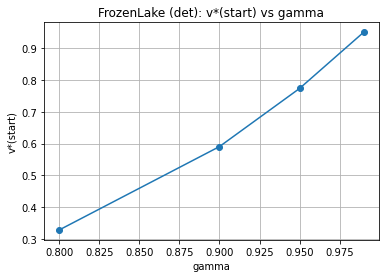

[(0.8, 0.32768000000000014), (0.9, 0.5904900000000002), (0.95, 0.7737809374999999), (0.99, 0.9509900498999999)]


In [26]:
import matplotlib.pyplot as plt

gammas = [0.8, 0.9, 0.95, 0.99]
start_state = 0

vstarts_fl = []
for g in gammas:
    pi_star, v_star = value_iteration(P_fl_det, gamma=g, theta=1e-10)
    vstarts_fl.append(float(v_star[start_state]))

plt.figure()
plt.plot(gammas, vstarts_fl, marker='o')
plt.xlabel("gamma")
plt.ylabel("v*(start)")
plt.title("FrozenLake (det): v*(start) vs gamma")
plt.grid(True)
plt.show()

print(list(zip(gammas, vstarts_fl)))


## Twoje zadanie: zrób to samo dla Gridworld i porównaj

1) Powtórz sweep po `γ` dla **Gridworld** (ten sam `gammas`, ten sam `start_state=0`).
2) Zrób jeden wspólny wykres z dwiema krzywymi:
   - FrozenLake (det lub slippery),
   - Gridworld.

### Kod (szablon — uzupełnij tylko brakujące fragmenty)


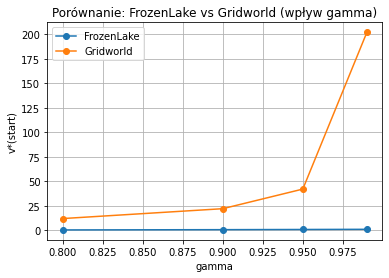

FrozenLake: [(0.8, 0.32768000000000014), (0.9, 0.5904900000000002), (0.95, 0.7737809374999999), (0.99, 0.9509900498999999)]
Gridworld: [(0.8, 11.899095668729178), (0.9, 21.977485287159247), (0.95, 41.99469264413066), (0.99, 201.99979758611693)]


In [27]:
vstarts_gw = []
for g in gammas:
    # TODO: policz v* w Gridworld (value_iteration albo policy_iteration)
    vstarts_gw.append(float(v_star[start_state]))

plt.figure()
plt.plot(gammas, vstarts_fl, marker='o', label="FrozenLake")
plt.plot(gammas, vstarts_gw, marker='o', label="Gridworld")
plt.xlabel("gamma")
plt.ylabel("v*(start)")
plt.title("Porównanie: FrozenLake vs Gridworld (wpływ gamma)")
plt.grid(True)
plt.legend()
plt.show()

print("FrozenLake:", list(zip(gammas, vstarts_fl)))
print("Gridworld:", list(zip(gammas, vstarts_gw)))


## Pytania do analizy (napisz 4–12 zdań)

1) Jak zmienia się `v*(start)` wraz z `γ` w FrozenLake?  
   (Podpowiedź: w det często widać zależność ~ `γ^L`, gdzie L to długość najlepszej ścieżki.)

2) Jak wygląda wpływ `γ` w Gridworld? Czy jest „silniejszy” / „słabszy” niż w FrozenLake?

3) Dlaczego te dwa światy zachowują się inaczej?  
   Użyj pojęć: epizodyczne vs continuing, horyzont czasowy, nagroda na końcu vs nagrody w nieskończonym czasie.

4) Czy przy bardzo dużym `γ` wartości w Gridworld robią się bardzo duże?  
   Jeśli tak, co to mówi o naturze continuing zadań i roli dyskontowania?


## Co oznacza `v(start)`?

`v(start)` to **wartość stanu startowego** (czyli wartość funkcji wartości w stanie, od którego zwykle zaczynamy):

$
v(start) = V_\pi(s_{\text{start}})
$

### Definicja (intuicja)
Jeśli zaczynamy w stanie `start` i dalej postępujemy zgodnie z polityką \(\pi\),
to `v(start)` jest **oczekiwaną (zdyskontowaną) sumą przyszłych nagród**:

$
V_\pi(s_{\text{start}})=\mathbb{E}_\pi\left[\sum_{t=0}^{\infty}\gamma^t R_{t+1}\ \middle|\ S_0=s_{\text{start}}\right]
$

Czyli to jedna liczba, która odpowiada na pytanie:

> **„Jak dobry jest ten sposób działania (polityka), jeśli zaczynam od stanu startowego?”**

---

## Jak interpretować `v(start)` w naszych środowiskach?

### 1) FrozenLake (epizodyczne, nagroda na końcu)
W FrozenLake nagroda jest zwykle:
- `+1` za wejście na pole `G` (goal),
- `0` w pozostałych przypadkach,
- epizod kończy się na `H` (hole) lub `G`.

W takim układzie `v(start)` można interpretować jako:

> **zdyskontowaną “szansę sukcesu”** (dotarcia do celu), uwzględniając ryzyko i γ.

- `slippery=True` obniża `v(start)`, bo ruch jest mniej kontrolowalny → częściej kończysz w dziurze.
- większe `γ` sprawia, że bardziej „opłaca się” dążyć do odległego celu (mniej karzesz opóźnienie).

### 2) Gridworld (ciągłe / continuing)
W Gridworld nagrody mogą pochodzić z:
- teleportów/specjalnych pól (dodatnie nagrody),
- kar za wyjście poza planszę (np. -1),
- ewentualnie kosztu kroku (jeśli go dodasz).

Wtedy `v(start)` mówi:

> **jakiego długoterminowego zysku (lub kosztu) oczekujemy**, startując z lewego górnego rogu (lub innego startu), jeśli działamy wg danej polityki.

---

## Dlaczego `v(start)` jest przydatne?

To **jedna liczba** (prosty wskaźnik), dzięki której można:
- porównywać różne polityki (losowa vs optymalna),
- porównywać różne ustawienia środowiska (np. `slippery`),
- porównywać różne parametry (`γ`, kary, nagrody teleportów),
- robić wykresy typu: *parametr → jakość zachowania*.

W praktyce to DP-odpowiednik „średniego returnu” znanego z RL,
tylko że tu liczymy go z modelu (bez próbkowania epizodów).

---

## Jak policzyć `v(start)` w notebooku?

Zakładamy, że masz:
- `v` jako wektor wartości stanów (np. wynik policy/value iteration albo policy evaluation),
- `start_state` (u nas zwykle `0`).

Wtedy:

```python
v_start = float(v[start_state])
print("v(start) =", v_start)


## Mini-projekt (DP): „Co zmienia optymalną politykę i wartość startu?”

### Kontekst
W rozdziale 4 zrobiliśmy Dynamic Programming dla tablicowych MDP:
- mamy **model** środowiska w postaci `P[s][a] = [(p, s2, r, terminated), ...]`,
- umiemy liczyć:
  - `v_π` (policy evaluation),
  - poprawiać politykę (policy improvement),
  - znajdować optimum: `π*`, `v*` (policy iteration / value iteration).

W tym mini-projekcie wykonasz **krótkie badanie**: jak zmiana parametrów środowiska lub zadania wpływa na:
- `v*(start)` — wartość stanu startowego,
- oraz (opcjonalnie) kształt polityki `π*` (strzałki).

---

## Co to jest `v(start)`?
`v(start)` to wartość funkcji wartości w stanie startowym:

$
v(start) = V_\pi(s_{\text{start}})
$

czyli oczekiwana (zdyskontowana) suma nagród, gdy startujesz w `start` i działasz według polityki `π`.
W praktyce to jedna liczba odpowiadająca na pytanie:

> **„Jak dobry jest ten sposób działania, jeśli startuję z typowego stanu startowego?”**

---

## Zadanie (obowiązkowe)
Twoim celem jest wykonać **eksperyment + analizę** (badanie). Zrób to w krokach:

### Krok 1 — wybierz środowisko
Wybierz jedno (albo zrób oba jako bonus):
- FrozenLake (`P_fl_det` lub `P_fl_slip`) — epizodyczne (Start - Goal, pamiętacie?:) ),
- Gridworld (`P_gw` lub większy Gridworld, jeśli jest w notebooku) — continuing (jak wyżej :) ).

Ustal `start_state` (zwykle `0`).

### Krok 2 — policz optimum (punkt odniesienia)
Policz `π*` i `v*` metodą DP:
- `value_iteration(...)` lub `policy_iteration(...)`.

Zapisz `v*(start)`.

### Krok 3 — wybierz 2 pytania badawcze i wykonaj eksperymenty
Wybierz **dwa** pytania z listy poniżej i wykonaj pomiary (sweep parametrów).

### Krok 4 — zrób wykresy
Dla każdego pytania przygotuj co najmniej **1 wykres**.
Minimalnie: wykres parametru (X) → `v*(start)` (Y).

### Krok 5 — opisz wnioski (krótko, ale konkretnie)
Napisz 8–15 zdań:
- co zmieniałeś,
- co zmierzyłeś,
- co wyszło i dlaczego (intuicja + odniesienie do definicji Bellmana).

---

## Pytania badawcze (wybierz 2)

### Pytanie A — wpływ `γ` (gamma)
**Hipoteza do sprawdzenia:** większe `γ` zwiększa znaczenie przyszłości i zmienia `v*(start)` oraz czasem politykę.

Zrób sweep po `γ`, np. `[0.8, 0.9, 0.95, 0.99]`.
Dla każdego `γ` policz `v*(start)`.

**Wykres:** `γ` vs `v*(start)`.

---

### Pytanie B — deterministyczne vs slippery (FrozenLake)
**Hipoteza do sprawdzenia:** stochastyczność (`slippery=True`) obniża `v*(start)` i może zmienić `π*`.

Porównaj:
- `P_fl_det` vs `P_fl_slip` (dla tego samego `γ`).

**Wykres:** dwa punkty/kolumny (det vs slippery) dla `v*(start)` (albo dwa przebiegi vs γ).

---

### Pytanie C — wpływ kar/nagród w Gridworld
**Hipoteza do sprawdzenia:** większe kary za ścianę lub mniejsze nagrody teleportów zmieniają `v*` i „kierunek” polityki.

Zrób sweep po jednym parametrze środowiska (jeśli masz builder świata):
- `wall_penalty ∈ {-1, -2, -5}`,
- lub nagrody teleportów (np. zmniejsz/zwieksz).

**Wykres:** parametr vs `v*(start)`.

---

### Pytanie D — PI vs VI jako metody numeryczne
**Hipoteza do sprawdzenia:** PI ma mniej iteracji „zewnętrznych”, a VI robi więcej prostych backupów.

Zmierz czas działania (np. `time.time()`) dla PI i VI na tym samym środowisku.

**Wykres:** słupki czasu (PI vs VI) lub liczba iteracji (jeśli zapisujesz liczbę iteracji).

> Uwaga: polityki mogą się różnić w stanach z remisami, ale `v*` powinno być takie samo (w granicach numeryki).

---

## Minimalne „snippet’y” (do wklejenia)

### 1) Jak policzyć `v(start)`
```python
start_state = 0
v_start = float(v[start_state])
print("v(start) =", v_start)


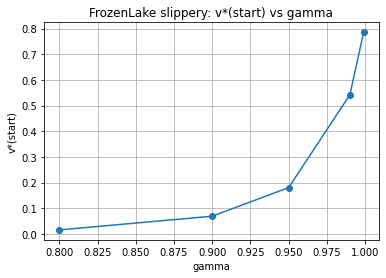

[(0.8, 0.015434338412935945), (0.9, 0.06889090447458562), (0.95, 0.18047157761948407), (0.99, 0.5420259308172148), (0.999, 0.7855332550140779)]


In [16]:
import matplotlib.pyplot as plt
import numpy as np

gammas = [0.8, 0.9, 0.95, 0.99,0.999]
vstarts = []

start_state = 0
for g in gammas:
    pi_star, v_star = value_iteration(P_fl_slip, gamma=g, theta=1e-10)
    vstarts.append(float(v_star[start_state]))

plt.figure()
plt.plot(gammas, vstarts, marker='o')
plt.xlabel("gamma")
plt.ylabel("v*(start)")
plt.title("FrozenLake slippery: v*(start) vs gamma")
plt.grid(True)
plt.show()

print(list(zip(gammas, vstarts)))



---

## Rozwiązania (dla prowadzącego) — usuń w wersji studenckiej


In [120]:
import numpy as np

def epsilon_greedy_policy_from_v(P, v: np.ndarray, gamma: float = 0.9, eps: float = 0.1) -> np.ndarray:
    """Rozwiązanie: ε‑greedy improvement na podstawie v (z obsługą remisów)."""
    assert 0.0 <= eps <= 1.0

    nS = v.shape[0]
    s0 = next(iter(P))
    nA = len(P[s0])

    pi_eps = np.zeros((nS, nA), dtype=float)

    for s in range(nS):
        q_values = np.zeros(nA, dtype=float)

        # Q(s,a)
        for a in range(nA):
            q = 0.0
            for (p, s2, r, terminated) in P[s][a]:
                if terminated:
                    q += float(p) * float(r)
                else:
                    q += float(p) * (float(r) + gamma * float(v[int(s2)]))
            q_values[a] = q

        # najlepsze akcje (remisy)
        max_q = np.max(q_values)
        best_actions = np.flatnonzero(np.isclose(q_values, max_q))

        # ε‑greedy rozkład
        pi_eps[s, :] = eps / nA
        pi_eps[s, best_actions] += (1.0 - eps) / len(best_actions)

    return pi_eps

### Dlaczego `v(start)` maleje, gdy ε rośnie?

`v_π(start)` to oczekiwany zdyskontowany return startując ze stanu `start`.
Gdy zwiększasz ε, **częściej wykonujesz losowe (często gorsze) akcje**, więc:
- częściej “marnujesz” dobre decyzje,
- częściej wpadasz w kary (np. uderzenia w ścianę),
- rzadziej wykorzystujesz najlepsze trajektorie.

Dlatego oczekiwana suma nagród spada, czyli `v(start)` maleje.

**Uwaga o strzałkach:** wizualizacja strzałkami zwykle pokazuje `argmax` w wierszu polityki.
Dla ε=0 i ε=0.1 `argmax` może być ten sam, mimo że rozkład jest inny (bo część masy idzie na gorsze akcje) — i to wystarcza, żeby `v(start)` spadło.


v*(start) = 14.95247168103039


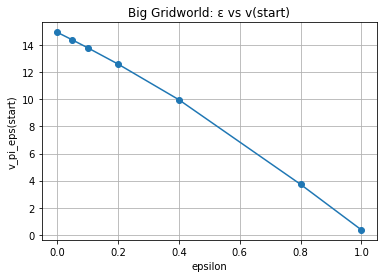

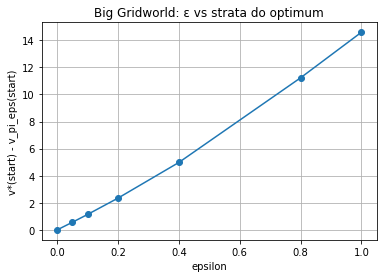

[(0.0, 14.952471681017748), (0.05, 14.390579046798985), (0.1, 13.81304774531356), (0.2, 12.607947723775814), (0.4, 9.975342376808541), (0.8, 3.7264977723476767), (1.0, 0.36302996357779865)]


In [121]:
import matplotlib.pyplot as plt

# 1) v* jako punkt odniesienia
pi_star_big, v_star_big = value_iteration(P_big, gamma=gamma_big, theta=1e-10)
v0_star = float(v_star_big[start_state])
print("v*(start) =", v0_star)

# 2) sweep po epsilon
eps_list = [0.0, 0.05, 0.1, 0.2, 0.4, 0.8, 1.0]
vals = []

for eps in eps_list:
    pi_eps = epsilon_greedy_policy_from_v(P_big, v_star_big, gamma=gamma_big, eps=eps)
    v_eps = iterative_policy_evaluation(P_big, pi_eps, gamma=gamma_big, theta=1e-10)
    vals.append(float(v_eps[start_state]))

# Wykres A: epsilon vs v(start)
plt.figure()
plt.plot(eps_list, vals, marker='o')
plt.xlabel("epsilon")
plt.ylabel("v_pi_eps(start)")
plt.title("Big Gridworld: ε vs v(start)")
plt.grid(True)
plt.show()

# Wykres B: epsilon vs strata do optimum
loss = [v0_star - x for x in vals]
plt.figure()
plt.plot(eps_list, loss, marker='o')
plt.xlabel("epsilon")
plt.ylabel("v*(start) - v_pi_eps(start)")
plt.title("Big Gridworld: ε vs strata do optimum")
plt.grid(True)
plt.show()

print(list(zip(eps_list, vals)))

### Porównanie siatek dla ε=0, ε=0.1, ε=1 (rozwiązanie)

Poniżej wypisujemy siatkę wartości `v_{π_ε}` oraz strzałki (argmax w wierszu) dla trzech ε.


In [122]:
import numpy as np

def pi_matrix_to_det(pi: np.ndarray) -> np.ndarray:
    return np.argmax(pi, axis=1).astype(int)

for eps in [0.0, 0.1, 1.0]:
    pi_eps = epsilon_greedy_policy_from_v(P_big, v_star_big, gamma=gamma_big, eps=eps)
    v_eps = iterative_policy_evaluation(P_big, pi_eps, gamma=gamma_big, theta=1e-10)

    print("\n" + "="*70)
    print("epsilon =", eps, "| v(start) =", float(v_eps[start_state]))
    pretty_matrix_as_grid(v_eps, nrow_big, ncol_big, decimals=1)

    print("\nStrzałki (argmax dla wizualizacji):")
    action_arrows(pi_matrix_to_det(pi_eps), nrow_big, ncol_big, arrows_big)


epsilon = 0.0 | v(start) = 14.952471681017748
[[15.  16.6 18.5 16.6 15.  13.5 12.1 11.2 10.1  9. ]
 [13.5 15.  16.6 15.  13.5 12.1 10.9 10.1  9.   8.1]
 [12.1 13.5 15.  13.5 12.1 10.9  9.8  9.   8.1  7.3]
 [10.9 12.1 13.5 12.1 10.9  9.8  8.8  8.1  7.3  6.6]
 [10.4 11.6 12.1 10.9  9.8  8.8  7.9  7.3  6.6  5.9]
 [11.6 12.9 11.6 10.4  9.4  8.5  7.6  6.9  6.2  5.6]
 [12.9 14.3 12.9 11.6 10.4  9.4  8.5  7.6  6.9  6.2]
 [11.6 12.9 11.6 10.4  9.4  8.5  7.6  6.9  6.2  5.6]
 [10.4 11.6 10.4  9.4  8.5  7.6  6.9  6.2  5.6  5. ]
 [ 9.4 10.4  9.4  8.5  7.6  6.9  6.2  5.6  5.   4.5]]

Strzałki (argmax dla wizualizacji):
→ → ↑ ← ← ← ← ↑ ← ←
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ ↓ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
→ ↑ ← ← ← ← ← ← ← ←
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑

epsilon = 0.1 | v(start) = 13.81304774531356
[[13.8 15.6 17.6 15.6 13.8 12.2 10.9 10.3  9.1  8.1]
 [12.3 13.9 15.6 13.9 12.3 10.9  9.7  9.2  8.2  7.2]
 [11.  12.3 13.8 12.3 11.   9.8  

### (Opcjonalnie) „reward rośnie” jak learning curve: zbieżność VI vs PI

W bandytach często rysuje się średni reward w funkcji kroków uczenia.
W DP nie uczymy się z próbek, ale możemy narysować analogicznie:
- jak zmienia się `v(start)` w kolejnych iteracjach **Value Iteration**,
- oraz w kolejnych iteracjach zewnętrznych **Policy Iteration**.

To jest wykres zbieżności metody numerycznej (nie wykres „uczenia z danych”),
ale daje intuicję, jak algorytmy dochodzą do optimum.


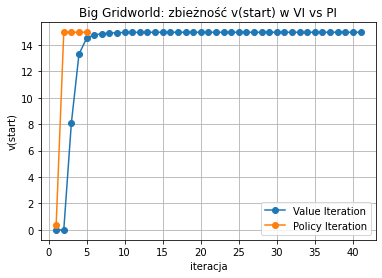

VI iters: 41 | PI outer iters: 5


In [123]:
import numpy as np
import matplotlib.pyplot as plt

def value_iteration_trace(P, gamma: float, theta: float, max_iters: int, start_state: int):
    nS = len(P)
    s0 = next(iter(P))
    nA = len(P[s0])
    v = np.zeros(nS, dtype=float)
    trace = []

    for it in range(max_iters):
        delta = 0.0
        for s in range(nS):
            v_old = v[s]
            best_q = -np.inf
            for a in range(nA):
                q = 0.0
                for (p, s2, r, terminated) in P[s][a]:
                    if terminated:
                        q += float(p) * float(r)
                    else:
                        q += float(p) * (float(r) + gamma * float(v[int(s2)]))
                best_q = max(best_q, q)
            v[s] = best_q
            delta = max(delta, abs(v_old - v[s]))
        trace.append(float(v[start_state]))
        if delta < theta:
            break
    return trace


def policy_iteration_trace(P, gamma: float, theta: float, max_outer_iters: int, start_state: int):
    nS = len(P)
    s0 = next(iter(P))
    nA = len(P[s0])
    pi = np.ones((nS, nA), dtype=float) / nA
    pi_det = None
    trace = []

    for it in range(max_outer_iters):
        v = iterative_policy_evaluation(P, pi, gamma=gamma, theta=theta)
        trace.append(float(v[start_state]))
        pi_det_new = greedy_policy_from_v(P, v, gamma=gamma)
        if pi_det is not None and np.array_equal(pi_det_new, pi_det):
            break
        pi = one_hot_policy(pi_det_new, nA)
        pi_det = pi_det_new

    return trace


trace_vi = value_iteration_trace(P_big, gamma=gamma_big, theta=1e-10, max_iters=500, start_state=start_state)
trace_pi = policy_iteration_trace(P_big, gamma=gamma_big, theta=1e-10, max_outer_iters=50, start_state=start_state)

plt.figure()
plt.plot(range(1, len(trace_vi)+1), trace_vi, marker='o', label="Value Iteration")
plt.plot(range(1, len(trace_pi)+1), trace_pi, marker='o', label="Policy Iteration")
plt.xlabel("iteracja")
plt.ylabel("v(start)")
plt.title("Big Gridworld: zbieżność v(start) w VI vs PI")
plt.grid(True)
plt.legend()
plt.show()

print("VI iters:", len(trace_vi), "| PI outer iters:", len(trace_pi))

### Zamknięcie: po co to było?

ε‑greedy pokazuje w kontrolowany sposób, że **eksploracja ma koszt** (spada wartość `v(start)`),
ale jest konieczna, gdy nie znamy modelu i musimy zbierać dane.

To naturalny wstęp do następnych tematów:
- **Monte Carlo**: oceniamy `v_π` / `q_π` na podstawie zwrotów z epizodów,
- **TD**: uczymy się na bieżąco przez bootstrap `r + γ V(s')`.

W obu przypadkach bez eksploracji (np. ε‑greedy) często nie zobaczymy dobrych stanów/akcji,
więc nie nauczymy się dobrej polityki.


In [131]:
# --- Rozwiązanie przykładowe: "świat gdzie ε boli" ---

nrow_hard, ncol_hard = 10, 10

# Dobre teleporty (jak wcześniej, można wzmocnić nagrody)
specials_good = [
    ((0, 2), (9, 2), 10.0),
    ((0, 7), (5, 7), 5.0),
    ((6, 1), (2, 8), 7.0),
]

# Pułapki: ujemne teleporty (przykład)
# Celowo blisko startu albo w miejscach "łatwych do przypadkowego wejścia"
specials_traps = [
    ((1, 0), (9, 9), -40.0),   # jeśli na starcie wybierzesz DOWN, wpadasz w pułapkę
    ((0, 1), (9, 8), -25.0),   # jeśli na starcie wybierzesz RIGHT, a to nieoptymalne, też boli
]

specials_hard = specials_good + specials_traps

# Zwiększona kara za ścianę
P_hard, nS_hard, nA_hard, _, _ = build_gridworld_special_P(
    nrow_hard, ncol_hard, specials_hard, wall_penalty=-15.0
)

gamma_hard = 0.9
start_state = 0
arrows = {0:'↑', 1:'→', 2:'↓', 3:'←'}

# 1) v* i π* (punkt odniesienia)
pi_star, v_star = value_iteration(P_hard, gamma=gamma_hard, theta=1e-10)

print("Świat HARD: v* (siatka):")
pretty_matrix_as_grid(v_star, nrow_hard, ncol_hard, decimals=1)
print("\nŚwiat HARD: π* (strzałki):")
action_arrows(pi_star, nrow_hard, ncol_hard, arrows)
print("\nv*(start) =", float(v_star[start_state]))

# 2) Porównanie ε=0 vs ε=0.1 vs ε=1.0
for eps in [0.0, 0.1, 1.0]:
    pi_eps = epsilon_greedy_policy_from_v(P_hard, v_star, gamma=gamma_hard, eps=eps)
    v_eps = iterative_policy_evaluation(P_hard, pi_eps, gamma=gamma_hard, theta=1e-10)
    print(f"eps={eps:>3} | v(start) = {float(v_eps[start_state])}")

# 3) Dodatkowo: różnica Δ między eps=0 i eps=0.1
pi_eps0  = epsilon_greedy_policy_from_v(P_hard, v_star, gamma=gamma_hard, eps=0.0)
pi_eps01 = epsilon_greedy_policy_from_v(P_hard, v_star, gamma=gamma_hard, eps=0.1)

v_eps0  = iterative_policy_evaluation(P_hard, pi_eps0,  gamma=gamma_hard, theta=1e-10)
v_eps01 = iterative_policy_evaluation(P_hard, pi_eps01, gamma=gamma_hard, theta=1e-10)

delta = float(v_eps0[start_state] - v_eps01[start_state])
print("\nΔ = v_eps0(start) - v_eps0.1(start) =", delta)


Świat HARD: v* (siatka):
[[-18.5 -20.5  18.5  16.6  15.   13.5  12.1  11.2  10.1   9. ]
 [-36.   15.   16.6  15.   13.5  12.1  10.9  10.1   9.    8.1]
 [ 12.1  13.5  15.   13.5  12.1  10.9   9.8   9.    8.1   7.3]
 [ 10.9  12.1  13.5  12.1  10.9   9.8   8.8   8.1   7.3   6.6]
 [ 10.4  11.6  12.1  10.9   9.8   8.8   7.9   7.3   6.6   5.9]
 [ 11.6  12.9  11.6  10.4   9.4   8.5   7.6   6.9   6.2   5.6]
 [ 12.9  14.3  12.9  11.6  10.4   9.4   8.5   7.6   6.9   6.2]
 [ 11.6  12.9  11.6  10.4   9.4   8.5   7.6   6.9   6.2   5.6]
 [ 10.4  11.6  10.4   9.4   8.5   7.6   6.9   6.2   5.6   5. ]
 [  9.4  10.4   9.4   8.5   7.6   6.9   6.2   5.6   5.    4.5]]

Świat HARD: π* (strzałki):
→ ↑ ↑ ← ← ← ← ↑ ← ←
↑ → ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ → ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ → ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ ↓ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
→ ↑ ← ← ← ← ← ← ← ←
→ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
→ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑

v*(start) = -18.453683997048252
eps=0.0 | v(start) = -18.453683997045555
eps=0.1 | v(start) = -20.832224771843645
e